# laser ablation

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, scipy, skimage, os
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,

    'svg.fonttype':'none',
    'pdf.fonttype': 42,

    'axes.linewidth': 0.5,

    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,

    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.major.pad': 1,
    'ytick.major.pad': 1,

    'axes.labelpad': 1
})

In [66]:
def confidence_interval(data, confidence=0.95):
    """
    Calculate the confidence interval for the mean of a NumPy array.

    Parameters:
        data (array-like): Input data (1D NumPy array or list).
        confidence (float): Confidence level (e.g., 0.95 for 95%).

    Returns:
        (float, float): Lower and upper bounds of the confidence interval.
    """
    data = np.array(data)
    n = len(data)
    if n < 2:
        raise ValueError("At least two data points are required")
    mean = np.mean(data)
    sem = scipy.stats.sem(data)  # standard error of the mean
    margin = sem * scipy.stats.t.ppf((1 + confidence) / 2.0, n - 1)
    return margin

In [67]:
# define the model
def fit_and_compare_exponential_by_group(data, x, y, type):
    x = data[x].to_numpy()
    y = data[y].to_numpy()

    levels = data[type].unique()
    g = (data[type] == levels[1]).astype(int)

    def model_two_groups(X, a1, b1, a2, b2):
        x, g = X
        mu1 = np.exp(a1 + b1 * x)
        mu2 = np.exp(a2 + b2 * x)
        return np.where(g == 0, mu1, mu2)

    # reasonable starting guess (works often)
    p0 = [0.0, 0.1, 0.0, 0.1]

    popt, pcov = scipy.optimize.curve_fit(
        model_two_groups,
        (x, g),
        y,
        p0=p0,
        maxfev=20000
    )

    a1, b1, a2, b2 = popt
    se = np.sqrt(np.diag(pcov))  # standard errors (a1,b1,a2,b2)

    def model_shared(x, a, b):
        return np.exp(a + b * x)
    
    popt0, _ = scipy.optimize.curve_fit(model_shared, x, y, p0=[0.0, 0.1], maxfev=20000)
    rss0 = np.sum((y - model_shared(x, *popt0))**2)

    rss1 = np.sum((y - model_two_groups((x, g), *popt))**2)

    n = len(y)
    p0n = 2
    p1n = 4

    F = ((rss0 - rss1) / (p1n - p0n)) / (rss1 / (n - p1n))
    p_value = 1 - scipy.stats.f.cdf(F, p1n - p0n, n - p1n)

    return {'param': popt, 'se':se, 'F-statistics':F, 'pvalue':p_value}

# Load the total data summary

In [68]:
data_collection = pd.read_excel('B:\\archive\\xtong\\xin home drive\\data_meroblastic\\majority_data_info.xlsx', sheet_name = 'lcii',
                                converters={'rep':int, 'cut_no':int, 'pre_cut_frame_num':int, 'post_cut_frame':int, 'no_analysis_method':str, 'rv_analysis_unit':str, 'rv_analysis_method':str, 'rv_analysis_date':str})
data_collection = data_collection.loc[data_collection['obj'] == '40x']

data_collection

,rep,experiment,experiment_type,cut_type,batch,cut_no,where,orientation,note,note2,...,rv_analysis_method,rv_analysis_date,rv_manual,rv_manual_angle1,rv_manual_angle2,Unnamed: 33,recoiling_analysis1,recoiling_analysis2,recoiling_analysis3,recoiling_analysis4
62,62,xin250328_lcii_wt,NaN,wt,2.0,1,middle,perp,NaN,NaN,...,automatic,250723_1351,NaN,NaN,NaN,NaN,8.0,4.255,18.0,13.464
63,63,xin250328_lcii_wt,NaN,wt,2.0,2,edge,perp,NaN,NaN,...,automatic,250723_1351,NaN,NaN,NaN,NaN,8.0,2.908,18.0,7.378
64,64,xin250328_lcii_wt,NaN,wt,2.0,3,middle,perp,NaN,NaN,...,automatic,250723_1351,NaN,NaN,NaN,NaN,9.0,4.686,19.0,18.742
65,65,xin250328_lcii_wt,NaN,wt,2.0,4,middle,perp,NaN,NaN,...,automatic,250723_1351,NaN,NaN,NaN,NaN,8.0,7.513,18.0,23.508
66,66,xin250328_lcii_wt,NaN,wt,2.0,5,edge,perp,phase2,NaN,...,automatic,250723_1351,NaN,NaN,NaN,NaN,8.0,2.585,18.0,6.694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013,1013,xin250710_lcii_wt,NaN,wt,2.0,59,ac,perp,NaN,NaN,...,manual,250724_1322,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1014,1014,xin250710_lcii_wt,NaN,wt,2.0,60,ac,para,NaN,NaN,...,manual,250724_1322,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1015,1015,xin250710_lcii_wt,NaN,wt,2.0,61,ac,perp,NaN,NaN,...,manual,250724_1322,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1016,1016,xin250710_lcii_wt,NaN,wt,2.0,62,NaN,NaN,cut the septum with little recoiling,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
replicates_experiments = data_collection['experiment'].unique()
print(replicates_experiments)

['xin250328_lcii_wt' 'xin250401_lcii_wt' 'xin250402_lcii_wt'
 'xin250403_lcii_wt' 'xin250408_lcii_wt' 'xin250411_lcii_wt'
 'xin250417_lcii_carhoa' 'xin250418_lcii_carhoa' 'xin250424_lcii_carhoa'
 'xin250625_lcii_carhoa' 'xin250626_lcii_carhoa' 'xin250703_lcii_wt'
 'xin250704_lcii_carhoa' 'xin250701_lcii_carhoa' 'xin250627_lcii_carhoa'
 'xin250710_lcii_wt']


# Rearrange the recoiling velocity data

In [70]:
data_collection.loc[data_collection['rv_analysis_method'] == 'automatic', 'rv'] = data_collection.loc[data_collection['rv_analysis_method'] == 'automatic', 'rv_automatic']
data_collection.loc[data_collection['rv_analysis_method'] == 'manual', 'rv'] = data_collection.loc[data_collection['rv_analysis_method'] == 'manual', 'rv_manual']
data_collection['rv'] = data_collection['rv'] * data_collection['pixel_size'] / data_collection['time_interval']

# Load the nematic order data

In [71]:
lcii_folder = ""
for replicates_experiment in replicates_experiments:
    no_file_name = [s for s in os.listdir(lcii_folder + replicates_experiment) if "no_analysis" in s and ".xlsx" in s][0]
    # print(no_file_name)
    no_file = pd.read_excel(lcii_folder + replicates_experiment+ '\\'+no_file_name, index_col=0)
    data_collection.loc[no_file.index, ['no_qxx', 'no_qxy', 'no_analysis_method']] = no_file.loc[:, ['no_qxx', 'no_qxy', 'no_analysis_method']]

# Count the replicate of each experiment

In [72]:
combo_counts = data_collection.groupby(["cut_type", "where", "orientation"]).size().reset_index(name='count')
display(combo_counts)

,cut_type,where,orientation,count
0,carhoa,ac,para,96
1,carhoa,ac,perp,20
2,carhoa,edge,para,22
3,carhoa,edge,perp,27
4,carhoa,middle,para,74
5,carhoa,middle,perp,202
6,wt,ac,para,58
7,wt,ac,perp,49
8,wt,edge,para,34
9,wt,edge,perp,49


# Plot the data

## 1. Nematic order ~ time

### preview

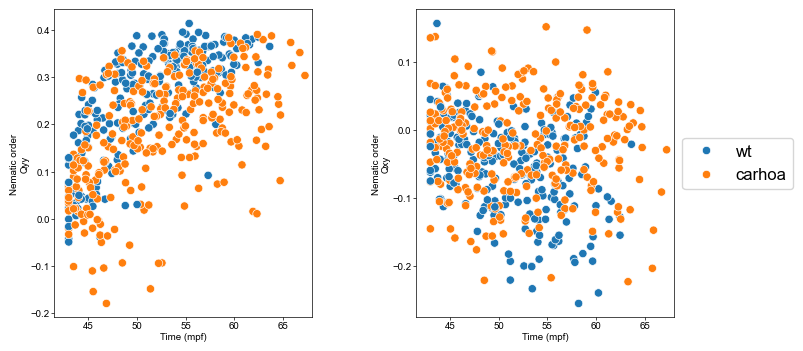

In [108]:
data_subset = data_collection.copy()
data_subset.loc[data_subset['orientation']=='para', 'no_qxx'] = -data_subset.loc[data_subset['orientation']=='para', 'no_qxx']

fig, axs = plt.subplots(1,2, figsize=[8, 4], gridspec_kw={'wspace':0.4})
sns.scatterplot(data = data_subset.loc[data_subset['where']=='middle'], x = 'mpf', y = 'no_qxx', ax=axs[0],
                hue = 'cut_type')
sns.scatterplot(data = data_subset.loc[data_subset['where']=='middle'], x = 'mpf', y = 'no_qxy', ax=axs[1],
                hue = 'cut_type')

axs[0].legend().set_visible(False)
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)

axs[0].set_ylabel('Nematic order\nQyy')
axs[1].set_ylabel('Nematic order\nQxy')
axs[0].set_xlabel('Time (mpf)')
axs[1].set_xlabel('Time (mpf)')

[ax.set_xlim(41.5, 68) for ax in axs]
[ax.set_xticks(np.arange(45, 68, 5)) for ax in axs]

plt.show()

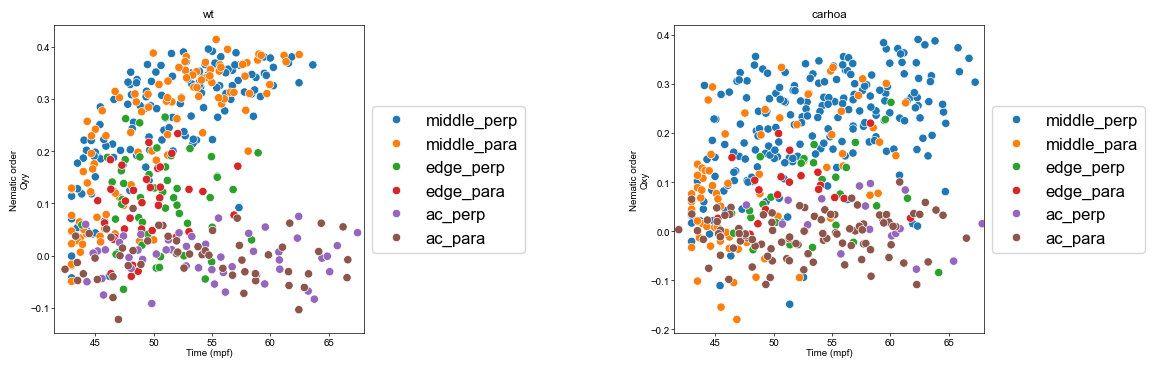

In [109]:
data_subset = data_collection.copy()
data_subset = data_subset.sort_values(['where', 'orientation'], ascending=False)
data_subset.loc[data_subset['orientation']=='para', 'no_qxx'] = -data_subset.loc[data_subset['orientation']=='para', 'no_qxx']
data_subset['sub_style'] = data_subset['where'] + '_' + data_subset['orientation']

# plot
fig, axs = plt.subplots(1,2, figsize=[12, 4], gridspec_kw={'wspace':1})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'mpf', y = 'no_qxx', ax=axs[0],
                hue = 'sub_style')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'mpf', y = 'no_qxx', ax=axs[1],
                hue = 'sub_style')

axs[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)

axs[0].set_ylabel('Nematic order\nQyy')
axs[1].set_ylabel('Nematic order\nQxy')
axs[0].set_xlabel('Time (mpf)')
axs[1].set_xlabel('Time (mpf)')

[ax.set_xlim(41.5, 68) for ax in axs]
[ax.set_xticks(np.arange(45, 68, 5)) for ax in axs]

axs[0].set_title('wt')
axs[1].set_title('carhoa')


plt.show()

### plot for the paper (fig. S5E)

#### qyy - middle

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 34.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 20.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\U

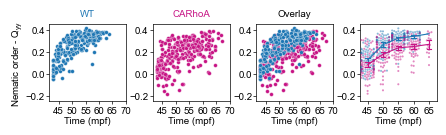

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 34.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 20.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\U

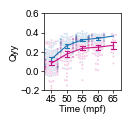

In [110]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['where']=='middle']
data_subset.loc[data_subset['orientation']=='para', 'no_qxx'] = -data_subset.loc[data_subset['orientation']=='para', 'no_qxx']
data_subset['time_bin'] = 5 * np.round(data_subset['mpf'] / 5).astype('int')

fig, axs = plt.subplots(1,4,figsize=[5, 1], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'mpf', y = 'no_qxx', ax=axs[0], legend=False,
                s=7.5, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'mpf', y = 'no_qxx', ax=axs[1], legend=False,
                s=7.5, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'mpf', y = 'no_qxx', ax=axs[2], legend=False,
                s=7.5, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'mpf', y = 'no_qxx', ax=axs[2], legend=False,
                s=7.5, color = 'tab:blue')

sns.swarmplot(data = data_subset, x = 'time_bin', y = 'no_qxx', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              size=1.5, alpha=0.5, zorder=5)
sns.pointplot(data = data_subset, x = 'time_bin', y = 'no_qxx', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              estimator='mean', errorbar=('ci', 95), lw=0.8, marker='_', markersize=0, markeredgewidth=1, zorder=6,
              capsize=0.3, err_kws={'linewidth': 0.8})

axs[0].set_ylabel('Nematic order - $\\mathregular{Q_{yy}}$')
axs[3].set_ylabel('Nematic order - $\\mathregular{Q_{yy}}$')

[ax.set_ylabel('') for ax in axs[1:]]

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)

[ax.set_xlabel('Time (mpf)') for ax in axs]
[ax.set_xlim(41.5, 70) for ax in axs[:3]]
[ax.set_xticks(np.arange(45, 71, 5)) for ax in axs[:3]]
[ax.set_ylim(-0.25, 0.45) for ax in axs[:4]]
[ax.set_yticks(np.arange(-0.2, 0.4, 0.2)) for ax in axs[:4]]

plt.savefig('qyymiddle-time_wt-and-carhoa.svg')
plt.show()


fig, ax = plt.subplots(figsize=[1, 1])
sns.swarmplot(data = data_subset, x = 'time_bin', y = 'no_qxx', ax=ax, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              size=1.5, alpha=0.2, zorder=5)
sns.pointplot(data = data_subset, x = 'time_bin', y = 'no_qxx', ax=ax, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              estimator='mean', errorbar=('ci', 95), lw=0.8, marker='_', markersize=0, markeredgewidth=1, zorder=6,
              capsize=0.3, err_kws={'linewidth': 0.8})

ax.set_ylim(-0.2, 0.6)
ax.set_yticks(np.arange(-0.2, 0.7, 0.2))
ax.set_ylabel('Qyy')
ax.set_xlabel('Time (mpf)')
plt.savefig('qyymiddle-time_wt-and-carhoa_2.svg')

plt.show()

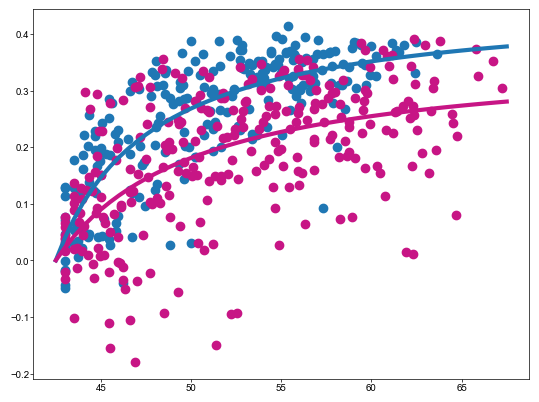

[0.45810624 5.30295249]
[0.3670521 7.7094085]
0.8012379453641806


In [111]:
from scipy.optimize import curve_fit
import numpy as np

# def hill(x, a, b, n):
#     return a * x**n / (b**n + x**n)

def hill(x, a, b):
    return a * x / (b + x)

colors = ['tab:blue', 'mediumvioletred']

x_pred = np.linspace(42.5, 42.5+0.5*50, 51)-42.5

x_data = data_subset.loc[data_subset['cut_type']=='wt', 'mpf'] - 42.5
y_data = data_subset.loc[data_subset['cut_type']=='wt', 'no_qxx']
popt_wt, pcov_wt = curve_fit(hill, x_data, y_data, p0=[max(y_data), np.median(x_data)])
y_pred0 = hill(x_pred, *popt_wt)
plt.plot(x_pred+42.5, y_pred0, color=colors[0], lw=3)
plt.scatter(x_data+42.5, y_data, color=colors[0])

x_data = data_subset.loc[data_subset['cut_type']=='carhoa', 'mpf'] - 42.5
y_data = data_subset.loc[data_subset['cut_type']=='carhoa', 'no_qxx']
popt_carhoa, pcov_carhoa = curve_fit(hill, x_data, y_data, p0=[max(y_data), np.median(x_data)])

y_pred1 = hill(x_pred, *popt_carhoa)
plt.plot(x_pred+42.5, y_pred1, color=colors[1], lw=3)
plt.scatter(x_data+42.5, y_data, color=colors[1])
plt.show()

print(popt_wt)
print(popt_carhoa)

potential_qxx_ratio = popt_carhoa[0] / popt_wt[0]
print(potential_qxx_ratio)

In [112]:
to_export = data_subset[['cut_type', 'mpf', 'no_qxx']].sort_values(['cut_type', 'mpf']).reset_index(drop=True)
display(to_export.head())
to_export.to_excel('nematic_order_wt_carhoa_Qyy-time.xlsx')

,cut_type,mpf,no_qxx
0,carhoa,43.0,-0.020793
1,carhoa,43.0,0.039280
2,carhoa,43.0,0.032473
3,carhoa,43.0,0.016646
4,carhoa,43.0,0.066541


In [113]:
# statistics
data_subset_stats = data_subset[['cut_type', 'time_bin', 'no_qxx']]

p_vals = []
for time_bin in np.unique(data_subset_stats['time_bin']):
    print(time_bin)
    groups = data_subset_stats[data_subset_stats['time_bin'] == time_bin]
    group1 = groups[groups['cut_type']=='wt'].no_qxx
    group2 = groups[groups['cut_type']=='carhoa'].no_qxx

    testgroup1, testgroup2 = group1, group2
    print('--Shapiro-Wilk test for normality--')
    stat, p = scipy.stats.shapiro(testgroup1)
    print("Control: W=%.4f, p=%.4f" % (stat, p))
    stat, p = scipy.stats.shapiro(testgroup2)
    print("Control: W=%.4f, p=%.4f" % (stat, p))
    # Levene’s test (center='median' is more robust to non-normal data)
    stat, p_val = scipy.stats.levene(testgroup1, testgroup2, center='mean')
    print('--Levene’s test for variance equity--')
    print("Levene’s test statistic =", stat)
    print("p-value =", p_val)
    # Mann–Whitney U test (two-sided)
    u_stat, p_val = scipy.stats.mannwhitneyu(testgroup1, testgroup2, alternative='two-sided')
    print('--Mann-Whitney U test (two-sided)--')
    print("Mann–Whitney U statistic =", u_stat)
    print("p-value =", p_val)
    print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.4f}.")
    print(" ")

    p_vals.append(p_val)

# Your raw p-values
raw_pvals = np.array(p_vals)
print("Raw:", np.round(raw_pvals,5))

from statsmodels.stats.multitest import multipletests
# Bonferroni
rej_bonf, pvals_bonf, _, _ = multipletests(raw_pvals, alpha=0.05, method='bonferroni')
print("Bonferroni corrected:", np.round(pvals_bonf, 4))

45
--Shapiro-Wilk test for normality--
Control: W=0.9733, p=0.1336
Control: W=0.9776, p=0.1861
--Levene’s test for variance equity--
Levene’s test statistic = 0.42556259554171344
p-value = 0.5151931806321846
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 3460.0
p-value = 0.008679843296071063
Statistical test, Mann-Whitney test: p = 0.0087.
 
50
--Shapiro-Wilk test for normality--
Control: W=0.9322, p=0.0022
Control: W=0.9462, p=0.0054
--Levene’s test for variance equity--
Levene’s test statistic = 5.7156869728675
p-value = 0.01828208534877853
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 3112.0
p-value = 9.867268654976767e-07
Statistical test, Mann-Whitney test: ***p < 0.001.
 
55
--Shapiro-Wilk test for normality--
Control: W=0.8854, p=0.0000
Control: W=0.9192, p=0.0006
--Levene’s test for variance equity--
Levene’s test statistic = 12.835729592646196
p-value = 0.0004793625663452502
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 3579.0


C:\Users\xtong\AppData\Local\Temp\ipykernel_1604\2059789684.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = scipy.stats.shapiro(testgroup1)


#### qxy - middle

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 35.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Use

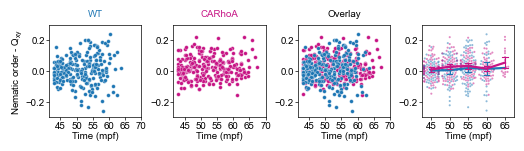

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 39.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 18.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Us

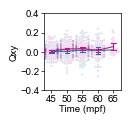

In [114]:
data_subset = data_collection.copy()
# data_subset = data_subset.loc[data_subset['cut_type']=='wt']
data_subset = data_subset.loc[data_subset['where']=='middle']
data_subset.loc[data_subset['orientation']=='perp', 'no_qxy'] = -data_subset.loc[data_subset['orientation']=='perp', 'no_qxy']
data_subset['time_bin'] = 5 * np.round(data_subset['mpf'] / 5).astype('int')
# data_subset['time_bin'] = (2.5 * np.round(data_subset['mpf'] / 2.5))

# plot
fig, axs = plt.subplots(1,4,figsize=[6, 1.2], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'mpf', y = 'no_qxy', ax=axs[0], legend=False,
                s=7.5, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'mpf', y = 'no_qxy', ax=axs[1], legend=False,
                s=7.5, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'mpf', y = 'no_qxy', ax=axs[2], legend=False,
                s=7.5, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'mpf', y = 'no_qxy', ax=axs[2], legend=False,
                s=7.5, color = 'tab:blue')

# sns.swarmplot(data = data_subset, x = 'time_bin', y = 'no_qxx', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'])
sns.swarmplot(data = data_subset, x = 'time_bin', y = 'no_qxy', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              size=1.5, alpha=0.5, zorder=5)
sns.pointplot(data = data_subset, x = 'time_bin', y = 'no_qxy', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              estimator='mean', errorbar=('ci', 95), lw=1.6, marker='_', markersize=0, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8}, zorder=6)

# sns.pointplot(data = data_subset, x = 'to_plot_x', y='rv',
#               color='black', ax=axs[3], zorder=10,
#               estimator='mean', errorbar=('ci', 95),
#               linestyle='none', marker="_", markersize=20, markeredgewidth=1,
#               capsize=0.3, err_kws={'linewidth': 0.8})
# sns.swarmplot(data = data_subset, x = 'time_bin', y = 'no_qxx', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'])


# axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)

axs[0].set_ylabel('Nematic order - $\\mathregular{Q_{xy}}$')
axs[3].set_ylabel('Nematic order - $\\mathregular{Q_{xy}}$')

[ax.set_ylabel('') for ax in axs[1:]]

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)

[ax.set_xlabel('Time (mpf)') for ax in axs]
[ax.set_xlim(41.5, 70) for ax in axs[:3]]
[ax.set_xticks(np.arange(45, 71, 5)) for ax in axs[:3]]
[ax.set_ylim(-0.3, 0.3) for ax in axs[:4]]
[ax.set_yticks(np.arange(-0.2, 0.35, 0.2)) for ax in axs[:4]]

plt.savefig('qxymiddle-time_wt-and-carhoa.svg')
plt.show()


fig, ax = plt.subplots(figsize=[1, 1])
sns.swarmplot(data = data_subset, x = 'time_bin', y = 'no_qxy', ax=ax, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              size=1.5, alpha=0.2, zorder=5)
sns.pointplot(data = data_subset, x = 'time_bin', y = 'no_qxy', ax=ax, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              estimator='mean', errorbar=('ci', 95), lw=0.8, marker='_', markersize=0, markeredgewidth=1, zorder=6,
              capsize=0.3, err_kws={'linewidth': 0.8})
ax.set_ylim(-0.4, 0.4)
ax.set_yticks(np.arange(-0.4, 0.5, 0.2))
ax.set_ylabel('Qxy')
ax.set_xlabel('Time (mpf)')
plt.savefig('qxymiddle-time_wt-and-carhoa_2.svg')

plt.show()

In [115]:
# statistics
data_subset_stats = data_subset[['cut_type', 'time_bin', 'no_qxy']]

p_vals = []
for time_bin in np.unique(data_subset_stats['time_bin']):
    print(time_bin)
    groups = data_subset_stats[data_subset_stats['time_bin'] == time_bin]
    group1 = groups[groups['cut_type']=='wt'].no_qxy
    group2 = groups[groups['cut_type']=='carhoa'].no_qxy

    testgroup1, testgroup2 = group1, group2
    print('--Shapiro-Wilk test for normality--')
    stat, p = scipy.stats.shapiro(testgroup1)
    print("Control: W=%.4f, p=%.4f" % (stat, p))
    stat, p = scipy.stats.shapiro(testgroup2)
    print("Control: W=%.4f, p=%.4f" % (stat, p))
    # Levene’s test (center='median' is more robust to non-normal data)
    stat, p_val = scipy.stats.levene(testgroup1, testgroup2, center='mean')
    print('--Levene’s test for variance equity--')
    print("Levene’s test statistic =", stat)
    print("p-value =", p_val)
    # Mann–Whitney U test (two-sided)
    u_stat, p_val = scipy.stats.mannwhitneyu(testgroup1, testgroup2, alternative='two-sided')
    print('--Mann-Whitney U test (two-sided)--')
    print("Mann–Whitney U statistic =", u_stat)
    print("p-value =", p_val)
    print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.4f}.")
    print(" ")

    p_vals.append(p_val)

# Your raw p-values
raw_pvals = np.array(p_vals)
print("Raw:", np.round(raw_pvals,5))

from statsmodels.stats.multitest import multipletests
# Bonferroni
rej_bonf, pvals_bonf, _, _ = multipletests(raw_pvals, alpha=0.05, method='bonferroni')
print("Bonferroni corrected:", np.round(pvals_bonf, 4))

45
--Shapiro-Wilk test for normality--
Control: W=0.9875, p=0.7076
Control: W=0.9852, p=0.5049
--Levene’s test for variance equity--
Levene’s test statistic = 1.6573816456246828
p-value = 0.19998047054805593
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 2644.0
p-value = 0.6360758351121123
Statistical test, Mann-Whitney test: p = 0.6361.
 
50
--Shapiro-Wilk test for normality--
Control: W=0.9818, p=0.4966
Control: W=0.9877, p=0.7451
--Levene’s test for variance equity--
Levene’s test statistic = 1.2782300145062417
p-value = 0.2603589933253756
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 1799.0
p-value = 0.19534887430068504
Statistical test, Mann-Whitney test: p = 0.1953.
 
55
--Shapiro-Wilk test for normality--
Control: W=0.9842, p=0.5137
Control: W=0.9861, p=0.7179
--Levene’s test for variance equity--
Levene’s test statistic = 9.64087074054139
p-value = 0.00233619974236849
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 2001.0
p-value 

C:\Users\xtong\AppData\Local\Temp\ipykernel_1604\450709349.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = scipy.stats.shapiro(testgroup1)


In [116]:
# statistics - replicate number
data_subset['bign'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')
data_subset['smalln'] = data_subset['experiment'] + data_subset['embryo_no'].astype('int').astype('str')

print('wt', len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].smalln)), len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].bign)), len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].experiment)))
print('carhoa', len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].smalln)), len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].bign)), len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].experiment)))

wt 145 21 8
carhoa 131 22 8


In [117]:
data_subset[['no_qxx', 'rv', 'where', 'mpf', 'experiment', 'cut_type', 'batch', 'embryo_no']].to_excel('rvmiddlevertical-noqyy_wt_and_carhoa_4_excel_fig5c.xlsx', index=False)

In [118]:
# export for excel fig. s6g

data_subset = data_collection.copy()
# data_subset = data_subset.loc[data_subset['cut_type']=='wt']
data_subset = data_subset.loc[data_subset['where']=='middle']
data_subset.loc[data_subset['orientation']=='perp', 'no_qxy'] = -data_subset.loc[data_subset['orientation']=='perp', 'no_qxy']
data_subset['time_bin'] = 5 * np.round(data_subset['mpf'] / 5).astype('int')

df_to_export = data_subset[['mpf', 'time_bin', 'no_qxx', 'no_qxy', 'cut_type', 'rep', 'experiment', 'batch', 'embryo_no']].copy()
df_to_export.columns = ['Time (mpf)', 'Binned time (mpf)', 'Nematic order Q_yy', 'Nematic order Q_xy', 'Type', 'Replicate #', 'Experiment date and type', 'Cluster #', 'Embryo #']
df_to_export.to_excel('qxx_qyymiddle-time_wt-and-carhoa_2_excel_figs6g.xlsx', index=False)
df_to_export

,Time (mpf),Binned time (mpf),Nematic order Q_yy,Nematic order Q_xy,Type,Replicate #,Experiment date and type,Cluster #,Embryo #
62,48.000000,50,0.327778,0.068917,wt,62,xin250328_lcii_wt,2.0,3.0
64,49.822833,50,0.333716,0.114240,wt,64,xin250328_lcii_wt,2.0,6.0
65,50.640333,50,0.364225,0.011219,wt,65,xin250328_lcii_wt,2.0,4.0
67,52.563167,55,0.389991,0.023211,wt,67,xin250328_lcii_wt,2.0,7.0
68,54.160500,55,0.340966,0.190242,wt,68,xin250328_lcii_wt,2.0,2.0
...,...,...,...,...,...,...,...,...,...
966,50.016667,50,-0.030068,0.008412,wt,966,xin250710_lcii_wt,1.0,1.0
970,53.400000,55,0.222854,0.201200,wt,970,xin250710_lcii_wt,1.0,3.0
973,56.190333,55,0.310547,0.155128,wt,973,xin250710_lcii_wt,1.0,11.0
988,43.000000,45,-0.129184,-0.075308,wt,988,xin250710_lcii_wt,2.0,17.0


## 2. Recoiling velocity ~ time

### preview

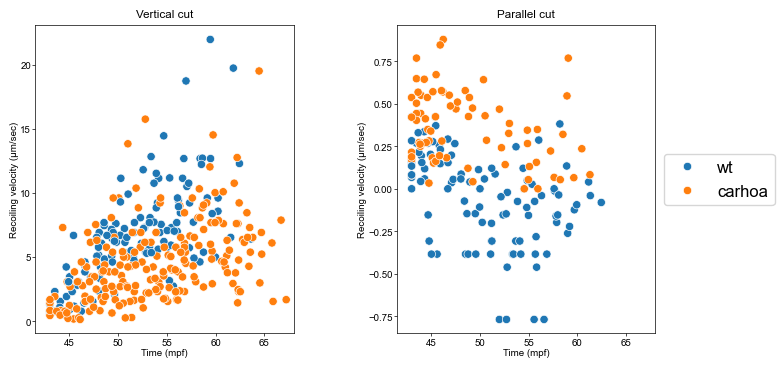

In [189]:
data_subset = data_collection.copy()
# data_subset = data_subset.loc[data_subset['cut_type']=='wt']
data_subset = data_subset.loc[data_subset['where']=='middle']
data_subset.loc[data_subset['orientation']=='para', 'no_qxx'] = -data_subset.loc[data_subset['orientation']=='para', 'no_qxx']

# plot
fig, axs = plt.subplots(1,2, figsize=[8, 4], gridspec_kw={'wspace':0.4})
sns.scatterplot(data = data_subset.loc[data_subset['orientation']=='perp'], x = 'mpf', y = 'rv', ax=axs[0],
                hue = 'cut_type')
sns.scatterplot(data = data_subset.loc[data_subset['orientation']=='para'], x = 'mpf', y = 'rv', ax=axs[1],
                hue = 'cut_type')

axs[0].legend().set_visible(False)
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)

axs[0].set_ylabel('Recoiling velocity (\u03BCm/sec)')
axs[1].set_ylabel('Recoiling velocity (\u03BCm/sec)')
axs[0].set_xlabel('Time (mpf)')
axs[1].set_xlabel('Time (mpf)')

axs[0].set_title('Vertical cut')
axs[1].set_title('Parallel cut')

[ax.set_xlim(41.5, 68) for ax in axs]
[ax.set_xticks(np.arange(45, 68, 5)) for ax in axs]
plt.show()

### plot for the paper (fig. S5F)

#### recoiling velocity - middle - vertical

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 58.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 43.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\U

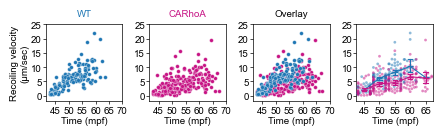

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 34.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Use

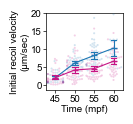

In [190]:
data_subset = data_collection.copy()
# data_subset = data_subset.loc[data_subset['cut_type']=='wt']
data_subset = data_subset.loc[(data_subset['where']=='middle') & (data_subset['orientation']=='perp')]
data_subset['time_bin'] = 5 * np.round(data_subset['mpf'] / 5).astype('int')


# plot
fig, axs = plt.subplots(1,4,figsize=[5, 1], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'mpf', y = 'rv', ax=axs[0], legend=False,
                s=7.5, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'mpf', y = 'rv', ax=axs[1], legend=False,
                s=7.5, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'mpf', y = 'rv', ax=axs[2], legend=False,
                s=7.5, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'mpf', y = 'rv', ax=axs[2], legend=False,
                s=7.5, color = 'tab:blue')

sns.swarmplot(data = data_subset, x = 'time_bin', y = 'rv', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              size=2, alpha=0.5, zorder=5)
sns.pointplot(data = data_subset, x = 'time_bin', y = 'rv', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              estimator='mean', errorbar=('ci', 95), lw=0.8, marker='_', markersize=4, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8}, zorder=6)

axs[0].set_ylabel('Recoiling velocity\n(\u03BCm/sec)')
axs[1].set_ylabel('')
axs[2].set_ylabel('')
axs[3].set_ylabel('')

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)

[ax.set_xlabel('Time (mpf)') for ax in axs]
[ax.set_xlim(41.5, 70) for ax in axs[:3]]
[ax.set_xticks(np.arange(45, 71, 5)) for ax in axs[:3]]
[ax.set_ylim(-2, 25) for ax in axs[:4]]
[ax.set_yticks(np.arange(0, 26, 5)) for ax in axs[:4]]

plt.savefig('rvmiddlevertical-time_wt_and_carhoa.svg')
plt.show()


fig, ax = plt.subplots(figsize=[1,1])
sns.swarmplot(data = data_subset.loc[data_subset['time_bin']<=60], x = 'time_bin', y = 'rv', ax=ax, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              size=1.5, alpha=.2, zorder=5)
sns.pointplot(data = data_subset.loc[data_subset['time_bin']<=60], x = 'time_bin', y = 'rv', ax=ax, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              estimator='mean', errorbar=('ci', 95), lw=0.8, marker='_', markersize=4, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8}, zorder=6)

ax.set_xlim(-0.5, 3.5)

ax.set_ylim(-1.5, 20)
ax.set_yticks(np.arange(0, 21, 5))
ax.set_xlabel('Time (mpf)')
ax.set_ylabel('Initial recoil velocity\n(\u03BCm/sec)')

plt.savefig('rvmiddlevertical-time_wt_and_carhoa_2.svg')
plt.show()

In [191]:
# statistics
data_subset_stats = data_subset[['cut_type', 'time_bin', 'rv']]

p_vals = []
for time_bin in np.unique(data_subset_stats['time_bin']):
    print(time_bin)
    groups = data_subset_stats[data_subset_stats['time_bin'] == time_bin]
    group1 = groups[groups['cut_type']=='wt'].rv
    group2 = groups[groups['cut_type']=='carhoa'].rv

    testgroup1, testgroup2 = group1, group2
    print('--Shapiro-Wilk test for normality--')
    stat, p = scipy.stats.shapiro(testgroup1)
    print("Control: W=%.4f, p=%.4f" % (stat, p))
    stat, p = scipy.stats.shapiro(testgroup2)
    print("Control: W=%.4f, p=%.4f" % (stat, p))
    # Levene’s test (center='median' is more robust to non-normal data)
    stat, p_val = scipy.stats.levene(testgroup1, testgroup2, center='mean')
    print('--Levene’s test for variance equity--')
    print("Levene’s test statistic =", stat)
    print("p-value =", p_val)
    # Mann–Whitney U test (two-sided)
    u_stat, p_val = scipy.stats.mannwhitneyu(testgroup1, testgroup2, alternative='two-sided')
    print('--Mann-Whitney U test (two-sided)--')
    print("Mann–Whitney U statistic =", u_stat)
    print("p-value =", p_val)
    print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.4f}.")
    print(" ")

    p_vals.append(p_val)

    # Your raw p-values
raw_pvals = np.array(p_vals)
print("Raw:", np.round(raw_pvals,5))

from statsmodels.stats.multitest import multipletests
# Bonferroni
rej_bonf, pvals_bonf, _, _ = multipletests(raw_pvals, alpha=0.05, method='bonferroni')
print("Bonferroni corrected:", pvals_bonf)
print("Bonferroni corrected:", np.round(pvals_bonf, 4))

45
--Shapiro-Wilk test for normality--
Control: W=0.8675, p=0.0008
Control: W=0.8496, p=0.0002
--Levene’s test for variance equity--
Levene’s test statistic = 0.8203996840556597
p-value = 0.3682615679228318
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 647.5
p-value = 0.6671279925272552
Statistical test, Mann-Whitney test: p = 0.6671.
 
50
--Shapiro-Wilk test for normality--
Control: W=0.9744, p=0.5222
Control: W=0.9222, p=0.0016
--Levene’s test for variance equity--
Levene’s test statistic = 5.014227703022276
p-value = 0.027576798159473
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 1586.5
p-value = 2.3472595504787766e-05
Statistical test, Mann-Whitney test: ***p < 0.001.
 
55
--Shapiro-Wilk test for normality--
Control: W=0.9466, p=0.0379
Control: W=0.8681, p=0.0001
--Levene’s test for variance equity--
Levene’s test statistic = 1.400316640083273
p-value = 0.23971934492487953
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 1864.5
p-valu

C:\Users\xtong\AppData\Local\Temp\ipykernel_1604\1848188973.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = scipy.stats.shapiro(testgroup1)


In [192]:
# statistics - replicate counts
data_subset['bign'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')
data_subset['smalln'] = data_subset['experiment'] + data_subset['embryo_no'].astype('int').astype('str')

print('wt',
      len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].experiment)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].bign)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].smalln)),
      len(data_subset.loc[data_subset['cut_type']=='wt']))

print('carhoa',
      len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].experiment)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].bign)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].smalln)),
      len(data_subset.loc[data_subset['cut_type']=='carhoa']))


wt 5 14 87 134
carhoa 8 21 110 202


#### recoiling velocity - middle - parallel

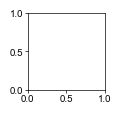

In [193]:
fig, ax = plt.subplots(figsize=(1,1))  # width x height in inches
ax_position = ax.get_position()
plt.show()

ax.get_box_aspect()

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 19.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 29.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


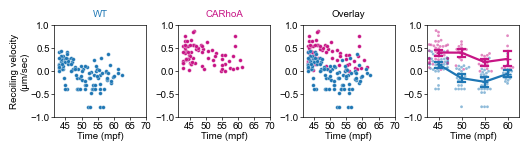

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 78.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 55.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 60.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\U

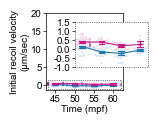

In [194]:
data_subset = data_collection.copy()
# data_subset = data_subset.loc[data_subset['cut_type']=='wt']
data_subset = data_subset.loc[(data_subset['where']=='middle') & (data_subset['orientation']=='para')]
data_subset['time_bin'] = 5 * np.round(data_subset['mpf'] / 5).astype('int')


# plot
fig, axs = plt.subplots(1,4,figsize=[6, 1.2], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'mpf', y = 'rv', ax=axs[0], legend=False,
                s=7.5, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'mpf', y = 'rv', ax=axs[1], legend=False,
                s=7.5, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'mpf', y = 'rv', ax=axs[2], legend=False,
                s=7.5, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'mpf', y = 'rv', ax=axs[2], legend=False,
                s=7.5, color = 'tab:blue')

sns.swarmplot(data = data_subset, x = 'time_bin', y = 'rv', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              size=2, alpha=0.5, zorder=5)
sns.pointplot(data = data_subset, x = 'time_bin', y = 'rv', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              estimator='mean', errorbar=('ci', 95), lw=1.6, marker='_', markersize=4, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 1.6}, zorder=6)

axs[0].set_ylabel('Recoiling velocity\n(\u03BCm/sec)')
axs[1].set_ylabel('')
axs[2].set_ylabel('')
axs[3].set_ylabel('')

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)


[ax.set_xlabel('Time (mpf)') for ax in axs]
[ax.set_xlim(41.5, 70) for ax in axs[:3]]
[ax.set_xticks(np.arange(45, 71, 5)) for ax in axs[:3]]
[ax.set_ylim(-1, 1) for ax in axs[:4]]

plt.savefig('rvmiddleparallel-time_wt_and_carhoa.svg')
plt.show()


fig, ax = plt.subplots(figsize=[2, 1])
ax.set_box_aspect(1)
sns.swarmplot(data = data_subset, x = 'time_bin', y = 'rv', ax=ax, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              size=1.5, alpha=0.2, zorder=1)
sns.pointplot(data = data_subset, x = 'time_bin', y = 'rv', ax=ax, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              estimator='mean', errorbar=('ci', 95), lw=0.8, marker='_', markersize=4, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8}, zorder=2)

ax.set_ylim(-1.5, 20)
ax.set_yticks(np.arange(0, 21, 5))
ax.set_ylabel('Initial recoil velocity\n(\u03BCm/sec)')
ax.set_xlabel('Time (mpf)')

ax.set_xlim(-0.5, 3.5)

# insets
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = ax.inset_axes([1, 5, 3.8, 12.5], transform=ax.transData,
                    #   xlim=[-0.25, 3.25], ylim=[-1, 1.5],
                      xticklabels=[],
                      # xticks=[],
                      yticks=np.arange(-1, 2, 0.5), yticklabels=np.arange(-1, 2, 0.5),
                      xlabel=' ', ylabel=' ',
                      zorder=3)
ax.add_patch(plt.Rectangle( (-0.4, -1), 3.8, 2.5, fill=False, clip_on=False, color = 'black', lw=0.5, ls=':', zorder=3))

for spine in axins.spines.values():
    spine.set_color('black') 
    spine.set_linewidth(0.5)
    spine.set_linestyle(':')
    spine.set_capstyle('butt')

sns.swarmplot(data = data_subset, x = 'time_bin', y = 'rv', ax=axins, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              size=1.5, alpha=0.2, zorder=4)
sns.pointplot(data = data_subset, x = 'time_bin', y = 'rv', ax=axins, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              estimator='mean', errorbar=('ci', 95), lw=0.8, marker='_', markersize=4, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8}, zorder=4)
axins.set_xticks([])

axins.set_xlim(-0.4, 3.4)
axins.set_ylim(-1, 1.5)

plt.savefig('rvmiddleparallel-time_wt_and_carhoa_2.svg')
plt.show()

In [195]:
# statistics
data_subset_stats = data_subset[['cut_type', 'time_bin', 'rv']]

p_vals = []
for time_bin in np.unique(data_subset_stats['time_bin']):
    print(time_bin)
    groups = data_subset_stats[data_subset_stats['time_bin'] == time_bin]
    group1 = groups[groups['cut_type']=='wt'].rv
    group2 = groups[groups['cut_type']=='carhoa'].rv

    testgroup1, testgroup2 = group1, group2
    print('--Shapiro-Wilk test for normality--')
    stat, p = scipy.stats.shapiro(testgroup1)
    print("Control: W=%.4f, p=%.4f" % (stat, p))
    stat, p = scipy.stats.shapiro(testgroup2)
    print("Control: W=%.4f, p=%.4f" % (stat, p))
    # Levene’s test (center='median' is more robust to non-normal data)
    stat, p_val = scipy.stats.levene(testgroup1, testgroup2, center='mean')
    print('--Levene’s test for variance equity--')
    print("Levene’s test statistic =", stat)
    print("p-value =", p_val)
    # Mann–Whitney U test (two-sided)
    u_stat, p_val = scipy.stats.mannwhitneyu(testgroup1, testgroup2, alternative='two-sided')
    print('--Mann-Whitney U test (two-sided)--')
    print("Mann–Whitney U statistic =", u_stat)
    print("p-value =", p_val)
    print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.4f}.")
    print(" ")

    p_vals.append(p_val)

    # Your raw p-values
raw_pvals = np.array(p_vals)
print("Raw:", np.round(raw_pvals,5))

from statsmodels.stats.multitest import multipletests
# Bonferroni
rej_bonf, pvals_bonf, _, _ = multipletests(raw_pvals, alpha=0.05, method='bonferroni')
print("Bonferroni corrected:", pvals_bonf)
print("Bonferroni corrected:", np.round(pvals_bonf, 4))

45
--Shapiro-Wilk test for normality--
Control: W=0.8959, p=0.0020
Control: W=0.9662, p=0.2577
--Levene’s test for variance equity--
Levene’s test statistic = 1.1119070311395252
p-value = 0.2949653120786328
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 301.0
p-value = 2.7946470789166355e-06
Statistical test, Mann-Whitney test: ***p < 0.001.
 
50
--Shapiro-Wilk test for normality--
Control: W=0.9107, p=0.0423
Control: W=0.9132, p=0.2030
--Levene’s test for variance equity--
Levene’s test statistic = 0.5374655420799249
p-value = 0.4685098452074714
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 6.5
p-value = 2.6345092196477833e-06
Statistical test, Mann-Whitney test: ***p < 0.001.
 
55
--Shapiro-Wilk test for normality--
Control: W=0.9543, p=0.2910
Control: W=0.9215, p=0.2983
--Levene’s test for variance equity--
Levene’s test statistic = 6.285842677879074
p-value = 0.016822667868865902
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 23.0
p-

In [196]:
# statistics - counts
data_subset['bign'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')
data_subset['smalln'] = data_subset['experiment'] + data_subset['embryo_no'].astype('int').astype('str')

print('wt',
      len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].experiment)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].bign)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].smalln)),
      len(data_subset.loc[data_subset['cut_type']=='wt']))

print('carhoa',
      len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].experiment)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].bign)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].smalln)),
      len(data_subset.loc[data_subset['cut_type']=='carhoa']))


wt 5 10 59 102
carhoa 7 16 58 74


#### recoiling velocity - surrounding cortex - vertical

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 14.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Us

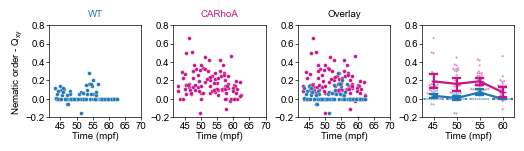

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 14.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 38.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 76.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Us

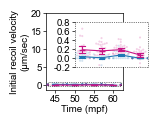

In [197]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['mpf']<=62.5]
data_subset = data_subset.loc[data_subset['mpf']>42.5]
data_subset = data_subset.loc[data_subset['where']=='ac']
data_subset['time_bin'] = 5 * np.round(data_subset['mpf'] / 5).astype('int')
# data_subset['time_bin'] = (2.5 * np.round(data_subset['mpf'] / 2.5))

# plot
fig, axs = plt.subplots(1,4,figsize=[6, 1.2], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'mpf', y = 'rv', ax=axs[0], legend=False,
                s=7.5, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'mpf', y = 'rv', ax=axs[1], legend=False,
                s=7.5, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'mpf', y = 'rv', ax=axs[2], legend=False,
                s=7.5, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'mpf', y = 'rv', ax=axs[2], legend=False,
                s=7.5, color = 'tab:blue')

# sns.swarmplot(data = data_subset, x = 'time_bin', y = 'no_qxx', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'])
sns.swarmplot(data = data_subset, x = 'time_bin', y = 'rv', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'], hue_order = ['wt', 'carhoa'],
              size=1.5, alpha=0.5, zorder=5)
sns.pointplot(data = data_subset, x = 'time_bin', y = 'rv', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'], hue_order = ['wt', 'carhoa'],
              estimator='mean', errorbar=('ci', 95), lw=1.6, marker='_', markersize=4, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 1.6}, zorder=6)

# sns.pointplot(data = data_subset, x = 'to_plot_x', y='rv',
#               color='black', ax=axs[3], zorder=10,
#               estimator='mean', errorbar=('ci', 95),
#               linestyle='none', marker="_", markersize=20, markeredgewidth=1,
#               capsize=0.3, err_kws={'linewidth': 0.8})
# sns.swarmplot(data = data_subset, x = 'time_bin', y = 'no_qxx', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'])


# axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)

axs[0].set_ylabel('Nematic order - $\\mathregular{Q_{xy}}$')
axs[3].set_ylabel('Nematic order - $\\mathregular{Q_{xy}}$')

[ax.set_ylabel('') for ax in axs[1:]]

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)

[ax.set_xlabel('Time (mpf)') for ax in axs]
[ax.set_xlim(41.5, 70) for ax in axs[:3]]
[ax.set_xticks(np.arange(45, 71, 5)) for ax in axs[:3]]
[ax.set_ylim(-0.2, 0.8) for ax in axs[:4]]
[ax.set_yticks(np.arange(-0.2, 0.9, 0.2)) for ax in axs[:4]]
# axs[3].set_xlim(0.5,7)

plt.savefig('rvac-time_wt_and_carhoa.svg')
plt.show()


fig, ax = plt.subplots(figsize=[2, 1])
ax.set_box_aspect(1)
sns.swarmplot(data = data_subset, x = 'time_bin', y = 'rv', ax=ax, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              size=1.5, alpha=0.2, zorder=5)
sns.pointplot(data = data_subset, x = 'time_bin', y = 'rv', ax=ax, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              estimator='mean', errorbar=('ci', 95), lw=0.8, marker='_', markersize=4, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8}, zorder=6)

ax.set_ylim(-1.5, 20)
ax.set_yticks(np.arange(0, 21, 5))
ax.set_ylabel('Initial recoil velocity\n(\u03BCm/sec)')
ax.set_xlabel('Time (mpf)')

# insets
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = ax.inset_axes([1, 5, 3.8, 12.5], transform=ax.transData,
                    #   xlim=[-10, 3.25], ylim=[-0.2, 0.8],
                      xticklabels=[],
                      xticks=[0, 1, 2, 3],
                      yticks=np.arange(-.2, 1, .2), yticklabels=np.round(np.arange(-.2, 1, .2), 1),
                      xlabel=' ', ylabel=' ',
                      zorder=10)
ax.add_patch(plt.Rectangle((-0.4, -0.2), 3.8, 1, fill=False, clip_on=False, color = 'black', lw=0.5, ls=':', zorder=30))

for spine in axins.spines.values():
    spine.set_color('black') 
    spine.set_linewidth(0.5)
    spine.set_linestyle(':')
    spine.set_capstyle('butt')

sns.swarmplot(data = data_subset, x = 'time_bin', y = 'rv', ax=axins, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'], hue_order = ['wt', 'carhoa'],
              size=1.5, alpha=0.2, zorder=5)
sns.pointplot(data = data_subset, x = 'time_bin', y = 'rv', ax=axins, hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'], hue_order = ['wt', 'carhoa'],
              estimator='mean', errorbar=('ci', 95), lw=.8, marker='_', markersize=4, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': .8}, zorder=6)
axins.set_xticks([])
axins.set_xlim(-0.4, 3.4)
axins.set_ylim(-0.2, 0.8)

plt.savefig('rvac-time_wt_and_carhoa_2.svg')
plt.show()

In [198]:
# statistics
data_subset_stats = data_subset[['cut_type', 'time_bin', 'rv']]

p_vals = []
for time_bin in np.unique(data_subset_stats['time_bin']):
    print(time_bin)
    groups = data_subset_stats[data_subset_stats['time_bin'] == time_bin]
    group1 = groups[groups['cut_type']=='wt'].rv
    group2 = groups[groups['cut_type']=='carhoa'].rv

    testgroup1, testgroup2 = group1, group2
    print('--Shapiro-Wilk test for normality--')
    stat, p = scipy.stats.shapiro(testgroup1)
    print("Control: W=%.4f, p=%.4f" % (stat, p))
    stat, p = scipy.stats.shapiro(testgroup2)
    print("Control: W=%.4f, p=%.4f" % (stat, p))
    # Levene’s test (center='median' is more robust to non-normal data)
    stat, p_val = scipy.stats.levene(testgroup1, testgroup2, center='mean')
    print('--Levene’s test for variance equity--')
    print("Levene’s test statistic =", stat)
    print("p-value =", p_val)
    # Mann–Whitney U test (two-sided)
    u_stat, p_val = scipy.stats.mannwhitneyu(testgroup1, testgroup2, alternative='two-sided')
    print('--Mann-Whitney U test (two-sided)--')
    print("Mann–Whitney U statistic =", u_stat)
    print("p-value =", p_val)
    print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.4f}.")
    print(" ")

    p_vals.append(p_val)
    
# Your raw p-values
raw_pvals = np.array(p_vals)
print("Raw:", np.round(raw_pvals,5))

from statsmodels.stats.multitest import multipletests
# Bonferroni
rej_bonf, pvals_bonf, _, _ = multipletests(raw_pvals, alpha=0.05, method='bonferroni')
print("Bonferroni corrected:", pvals_bonf)
print("Bonferroni corrected:", np.round(pvals_bonf, 4))

45
--Shapiro-Wilk test for normality--
Control: W=0.9007, p=0.0261
Control: W=0.8329, p=0.0028
--Levene’s test for variance equity--
Levene’s test statistic = 11.625778006309188
p-value = 0.0014718389017357098
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 70.0
p-value = 8.625226811568253e-05
Statistical test, Mann-Whitney test: ***p < 0.001.
 
50
--Shapiro-Wilk test for normality--
Control: W=0.6795, p=0.0000
Control: W=0.9004, p=0.0159
--Levene’s test for variance equity--
Levene’s test statistic = 16.87075407982837
p-value = 0.00016255276221867576
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 83.5
p-value = 2.0519278428345197e-05
Statistical test, Mann-Whitney test: ***p < 0.001.
 
55
--Shapiro-Wilk test for normality--
Control: W=0.8292, p=0.0012
Control: W=0.9266, p=0.0451
--Levene’s test for variance equity--
Levene’s test statistic = 1.430939503350172
p-value = 0.2372530332098675
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 116.

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [199]:
# statistics - counts
data_subset['bign'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')
data_subset['smalln'] = data_subset['experiment'] + data_subset['embryo_no'].astype('int').astype('str')

print('wt',
      len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].experiment)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].bign)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='wt'].smalln)),
      len(data_subset.loc[data_subset['cut_type']=='wt']))

print('carhoa',
      len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].experiment)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].bign)),
      len(np.unique(data_subset.loc[data_subset['cut_type']=='carhoa'].smalln)),
      len(data_subset.loc[data_subset['cut_type']=='carhoa']))


wt 2 5 45 89
carhoa 7 14 66 103


In [200]:
# export for excel fig. s6h

data_subset1 = data_collection.copy()
data_subset1 = data_subset1.loc[data_subset1['mpf']<=62.5]
data_subset1 = data_subset1.loc[data_subset1['mpf']>42.5]
data_subset1 = data_subset1.loc[data_subset1['where'] == 'ac']
print(len(data_subset1))

data_subset2 = data_collection.copy()
data_subset2 = data_subset2.loc[data_subset2['where'] == 'middle']
print(len(data_subset2))


data_subset = pd.concat([data_subset1, data_subset2])
data_subset['time_bin'] = 5 * np.round(data_subset['mpf'] / 5).astype('int')

# df_to_export = data_subset

df_to_export = data_subset[['mpf', 'time_bin', 'rv', 'cut_type', 'where', 'orientation', 'rep', 'experiment', 'batch', 'embryo_no']].copy()
df_to_export.columns = ['Time (mpf)', 'Binned time (mpf)', 'Recoiling velocity (um/sec)', 'Type', 'Ablation position', 'Ablation orientation', 'Replicate #', 'Experiment date and type', 'Cluster #', 'Embryo #']
df_to_export.to_excel('rv-time_wt_and_carhoa_2_excel_figs6h.xlsx', index=False)
df_to_export

192
512


,Time (mpf),Binned time (mpf),Recoiling velocity (um/sec),Type,Ablation position,Ablation orientation,Replicate #,Experiment date and type,Cluster #,Embryo #
413,43.016667,45,0.083256,carhoa,ac,para,413,xin250417_lcii_carhoa,1.0,5.0
416,47.733333,50,0.372009,carhoa,ac,para,416,xin250417_lcii_carhoa,1.0,6.0
417,50.696500,50,0.336499,carhoa,ac,para,417,xin250417_lcii_carhoa,1.0,3.0
423,57.350000,55,0.141150,carhoa,ac,perp,423,xin250417_lcii_carhoa,1.0,8.0
424,58.283333,60,0.122573,carhoa,ac,perp,424,xin250417_lcii_carhoa,1.0,9.0
...,...,...,...,...,...,...,...,...,...,...
966,50.016667,50,0.000000,wt,middle,para,966,xin250710_lcii_wt,1.0,1.0
970,53.400000,55,5.351733,wt,middle,perp,970,xin250710_lcii_wt,1.0,3.0
973,56.190333,55,8.942078,wt,middle,perp,973,xin250710_lcii_wt,1.0,11.0
988,43.000000,45,0.000000,wt,middle,para,988,xin250710_lcii_wt,2.0,17.0


## 3. Recoiling velocity at 50-55 mpf

### plot for the paper (fig. 5B)

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


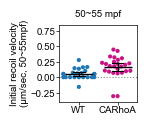

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['where'] == 'ac']
data_subset = data_subset.loc[(data_subset['mpf']>42.5+10-2.5) & (data_subset['mpf']<42.5+10+2.5)]


# plot
fig, ax = plt.subplots(figsize=[1, 1])

sns.swarmplot(data = data_subset, x = 'cut_type', y ='rv', ax = ax, size=3, hue = 'cut_type', legend=False, 
              order = ['wt', 'carhoa'], palette = ['mediumvioletred', 'tab:blue'])
sns.pointplot(data = data_subset, x = 'cut_type', y ='rv',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})


ax.set_xticks(range(2))
ax.set_xticklabels(['WT', 'CARhoA'])
ax.set_ylim(-0.4, 0.85)
ax.set_yticks([-0.25, 0, 0.25, 0.5, 0.75])
ax.set_xlabel('')
ax.axhline(y=0, ls=':', color='grey', zorder=-10, lw=0.8)

ax.set_ylabel('Initial recoil velocity\n(\u03bcm/sec, 50~55mpf)', fontsize=7)

# fig.suptitle('Surrounding cortex\n(Phase 2)', fontsize=12)
ax.set_title('50~55 mpf', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=12)
plt.savefig('rvac-50-55mpf_wt_and_carhoa.svg')
plt.show()

In [ ]:
to_export = data_subset[['cut_type', 'rv']].sort_values('cut_type').reset_index(drop=True)
display(to_export)
to_export.to_excel('rvac-50-55mpf_wt_and_carhoa.xlsx')

,cut_type,rv
0,carhoa,0.336499
1,carhoa,0.090243
2,carhoa,0.062476
3,carhoa,0.069829
4,carhoa,0.307753
5,carhoa,0.135632
6,carhoa,0.173488
7,carhoa,0.105284
8,carhoa,0.448806
9,carhoa,0.097764


In [ ]:
# statistics
group1 = data_subset[data_subset['cut_type'] == 'wt'].rv #wt
group2 = data_subset[data_subset['cut_type'] == 'carhoa'].rv #carhoa

# Shapiro-Wilk test
stat_group1, p_group1 = scipy.stats.shapiro(group1)
stat_group2, p_group2 = scipy.stats.shapiro(group2)

print('--Shapiro-Wilk test for normality--')
print("Control: W=%.4f, p=%.4f" % (stat_group1, p_group1))
print("CARhoA: W=%.4f, p=%.4f" % (stat_group2, p_group2))
print(' ')

# Rule of thumb:
# If p > 0.05 → data are not significantly different from normal (i.e. approx. normal).
# If p <= 0.05 → reject normality assumption.

# Optional: visualize with histogram + QQ-plot
# fig, axs = plt.subplots(2, 2, figsize=(10,6))

# sns.histplot(group1, kde=True, ax=axs[0,0])
# axs[0,0].set_title("Control histogram")
# scipy.stats.probplot(group1, dist="norm", plot=axs[0,1])
# axs[0,1].set_title("Control QQ-plot")

# sns.histplot(group2, kde=True, ax=axs[1,0])
# axs[1,0].set_title("CARhoA histogram")
# scipy.stats.probplot(group2, dist="norm", plot=axs[1,1])
# axs[1,1].set_title("CARhoA QQ-plot")

# plt.tight_layout()
# plt.show()

# Levene’s test (center='median' is more robust to non-normal data)
stat, p_val = scipy.stats.levene(group1, group2, center='median')

print('--Levene’s test for variance equity--')
print("Levene’s test statistic =", stat)
print("p-value =", p_val)
print(" ")

# Mann–Whitney U test (two-sided)
u_stat, p_val = scipy.stats.mannwhitneyu(group1, group2, alternative='two-sided')
print('--Mann-Whitney U test (two-sided)--')
print("Mann–Whitney U statistic =", u_stat)
print("p-value =", p_val)
print(" ")

print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.4f}.")

# Interpretation:
# If p < 0.05 → significant difference between groups
# If p >= 0.05 → no significant difference

--Shapiro-Wilk test for normality--
Control: W=0.901, p=0.027
CARhoA: W=0.869, p=0.004
 
--Levene’s test for variance equity--
Levene’s test statistic = 3.8893029580499054
p-value = 0.05462440190084346
 
--Mann-Whitney U test (two-sided)--
Mann–Whitney U statistic = 104.0
p-value = 0.00015345018770526853
 
Statistical test, Mann-Whitney test: ***p < 0.001.


In [ ]:
# statistics - counts
data_subset['bign'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')
data_subset['smalln'] = data_subset['experiment'] + data_subset['embryo_no'].astype('int').astype('str')

print('wt',
      len(np.unique(data_subset[data_subset['cut_type'] == 'wt'].experiment)),
      len(np.unique(data_subset[data_subset['cut_type'] == 'wt'].bign)),
      len(np.unique(data_subset[data_subset['cut_type'] == 'wt'].smalln)),
      len(data_subset[data_subset['cut_type'] == 'wt']))
print('carhoa',
      len(np.unique(data_subset[data_subset['cut_type'] == 'carhoa'].experiment)),
      len(np.unique(data_subset[data_subset['cut_type'] == 'carhoa'].bign)),
      len(np.unique(data_subset[data_subset['cut_type'] == 'carhoa'].smalln)),
      len(data_subset[data_subset['cut_type'] == 'carhoa']))

wt 2 5 14 23
carhoa 6 11 21 25


### plot for the paper (fig. 4A')

c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 53.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 41.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 36.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\U

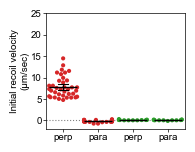

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['cut_type'] == 'wt']
data_subset = data_subset.loc[(data_subset['mpf']>42.5+10-2.5) & (data_subset['mpf']<42.5+10+2.5)]
data_subset['to_plot_x'] = data_subset['where'] + data_subset['orientation']
data_subset = data_subset.loc[data_subset['to_plot_x'].isin(['middleperp', 'middlepara', 'acperp', 'acpara'])]

fig, ax = plt.subplots(figsize=[1.8, 1.5], gridspec_kw={'wspace': 0.35})
sns.swarmplot(data = data_subset, x = 'to_plot_x', y ='rv', ax = ax, size=3, hue = 'where', legend=False,
              palette = ['tab:red', 'tab:green'])
sns.pointplot(data = data_subset, x = 'to_plot_x', y='rv',
              color='black', ax=ax, zorder=10,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})

ax.axhline(y=0, ls=':', color='grey', zorder=-10, lw=0.8)

ax.set_xticks(range(4))
ax.set_xticklabels(['perp', 'para', 'perp', 'para'])
ax.set_ylim(-2, 25)
ax.set_yticks(np.arange(0, 26, 5)) 

ax.set_xlabel('', fontsize=7)
ax.set_ylabel('Initial recoil velocity\n(\u03bcm/sec)', fontsize=7)

plt.savefig('cb_ac_perp_para.svg')
plt.show()

In [ ]:
# export for excel
df_all = data_subset[['where', 'orientation', 'rv']]
df_all = df_all.replace({'middle':'actin_cable', 'ac':"surrounding_cortex"})
df_all = df_all.sort_values('where').reset_index(drop=True)
df_all.to_excel('cb_ac_perp_para_excel_fig4Aprime.xlsx', index=False)

In [ ]:
# statistics
group1 = data_subset.loc[data_subset['to_plot_x'] == 'middleperp'].rv
group2 = data_subset.loc[data_subset['to_plot_x'] == 'middlepara'].rv
group3 = data_subset.loc[data_subset['to_plot_x'] == 'acperp'].rv
group4 = data_subset.loc[data_subset['to_plot_x'] == 'acpara'].rv

stat, p_val = scipy.stats.kruskal(group1, group2, group3, group4)
print(f"Kruskal–Wallis: H={stat:.3f}, p={p_val:.4f}")

import itertools
from statsmodels.stats.multitest import multipletests

groups = {"g1": group1, "g2": group2, "g3": group3, "g4": group4}
pairs = list(itertools.combinations(groups.keys(), 2))

raw_pvals = []
labels = []

for a, b in pairs:
    stat, p = scipy.stats.mannwhitneyu(groups[a], groups[b], alternative="two-sided")
    raw_pvals.append(p)
    labels.append(f"{a} vs {b}")

# Holm–Bonferroni correction
rej, pvals_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method="bonferroni")

# Report results
for lbl, raw, adj, r in zip(labels, raw_pvals, pvals_corrected, rej):
    print(f"{lbl}: raw p={raw:.4f}, adj p={adj:.4f}, significant={r}")

Kruskal–Wallis: H=68.860, p=0.0000
g1 vs g2: raw p=0.0000, adj p=0.0000, significant=True
g1 vs g3: raw p=0.0000, adj p=0.0000, significant=True
g1 vs g4: raw p=0.0000, adj p=0.0000, significant=True
g2 vs g3: raw p=0.0046, adj p=0.0274, significant=True
g2 vs g4: raw p=0.0009, adj p=0.0053, significant=True
g3 vs g4: raw p=0.4892, adj p=1.0000, significant=False


In [ ]:
# statistics - counts
data_subset['bign'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')
data_subset['smalln'] = data_subset['experiment'] + data_subset['embryo_no'].astype('int').astype('str')

# data_subset['smalln'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')+ data_subset['embryo_no'].astype('int').astype('str')

print('acperp',
      len(np.unique(data_subset.loc[data_subset['to_plot_x']=='acperp'].experiment)),
      len(np.unique(data_subset.loc[data_subset['to_plot_x']=='acperp'].bign)),
      len(np.unique(data_subset.loc[data_subset['to_plot_x']=='acperp'].smalln)),
      len(data_subset.loc[data_subset['to_plot_x']=='acperp']))
print('acpara',
       len(np.unique(data_subset.loc[data_subset['to_plot_x']=='acpara'].experiment)),
      len(np.unique(data_subset.loc[data_subset['to_plot_x']=='acpara'].bign)),
      len(np.unique(data_subset.loc[data_subset['to_plot_x']=='acpara'].smalln)),
      len(data_subset.loc[data_subset['to_plot_x']=='acpara']))
print('middleperp',
      len(np.unique(data_subset.loc[data_subset['to_plot_x']=='middleperp'].experiment)),
      len(np.unique(data_subset.loc[data_subset['to_plot_x']=='middleperp'].bign)),
      len(np.unique(data_subset.loc[data_subset['to_plot_x']=='middleperp'].smalln)),
      len(data_subset.loc[data_subset['to_plot_x']=='middleperp']))
print('middlepara',
      len(np.unique(data_subset.loc[data_subset['to_plot_x']=='middlepara'].experiment)),
      len(np.unique(data_subset.loc[data_subset['to_plot_x']=='middlepara'].bign)),
      len(np.unique(data_subset.loc[data_subset['to_plot_x']=='middlepara'].smalln)),
      len(data_subset.loc[data_subset['to_plot_x']=='middlepara']))

acperp 2 5 11 11
acpara 2 5 12 12
middleperp 5 13 31 37
middlepara 4 8 28 28


## 4. Recoiling velocity ~ nematic order

### preview

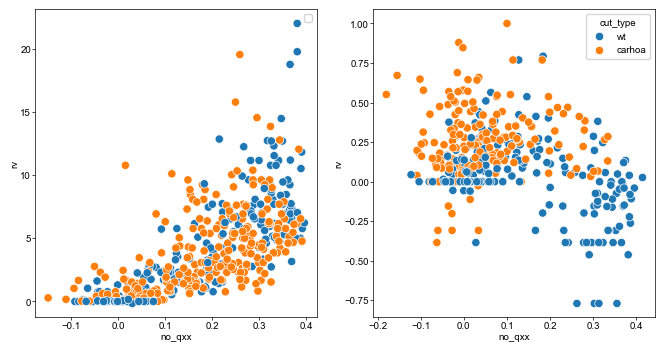

In [ ]:
data_subset = data_collection.copy()
# data_subset = data_subset.loc[data_subset['orientation'] == 'perp']
data_subset.loc[data_subset['orientation']=='para', 'no_qxx'] = -data_subset.loc[data_subset['orientation']=='para', 'no_qxx']

fig, axs = plt.subplots(1,2, figsize=[8, 4])
sns.scatterplot(data = data_subset.loc[data_subset['orientation'] == 'perp'], x = 'no_qxx', y = 'rv', ax=axs[0],
                hue = 'cut_type')
sns.scatterplot(data = data_subset.loc[data_subset['orientation'] == 'para'], x = 'no_qxx', y = 'rv', ax=axs[1],
                hue = 'cut_type')
# sns.scatterplot(data = data_subset.loc[data_subset['where']=='middle'], x = 'mpf', y = 'no_qxy', ax=axs[1],
#                 hue = 'cut_type')
axs[0].legend("")
plt.show()

### plot for the paper (fig. 4B)

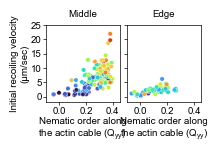

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['cut_type'] == 'wt']
data_subset = data_subset.loc[data_subset['orientation']=='perp']
data_subset = data_subset.loc[data_subset['where'].isin(['middle', 'edge'])]

# plot
fig, axs = plt.subplots(1,2,figsize=[2, 1], gridspec_kw={'wspace': 0.1}, sharey=True)
sns.scatterplot(data = data_subset.loc[data_subset['where']=='middle'], x = 'no_qxx', y = 'rv', ax=axs[0], legend=False,
                s=10,
                hue = 'mpf', hue_norm = (43, 65), palette = 'turbo')
sns.scatterplot(data = data_subset.loc[data_subset['where']=='edge'], x = 'no_qxx', y = 'rv', ax=axs[1], legend=False,
                s=10,
                hue = 'mpf', hue_norm = (43, 65), palette = 'turbo')


axs[0].set_ylabel('Initial recoiling velocity\n(\u03BCm/sec)')
# axs[1].set_ylabel('')
# axs[2].set_ylabel('')

axs[0].set_title('Middle', fontsize=7)
axs[1].set_title('Edge', fontsize=7)
# axs[2].set_title('Overlay', fontsize=12)


[ax.set_xlabel('Nematic order along\nthe actin cable ($\\mathregular{Q_{yy}}$)') for ax in axs]
[ax.set_xlim(-0.1, 0.45) for ax in axs]
[ax.set_xticks(np.arange(0, 0.5, 0.2)) for ax in axs]
[ax.set_ylim(-2, 25) for ax in axs]
[ax.set_yticks(np.arange(0, 26, 5)) for ax in axs]

# [ax.set_yscale('log') for ax in axs]
plt.savefig('rvwtvertical-no_middle_and_edge.svg')
plt.show()


In [ ]:
# statistics - counts
data_subset['bign'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')
data_subset['smalln'] = data_subset['experiment'] + data_subset['embryo_no'].astype('int').astype('str')

print('middle',
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].experiment)),
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].bign)),
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].smalln)),
      len(data_subset.loc[data_subset['where']=='middle']))
print('edge',
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].experiment)),
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].bign)),
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].smalln)),
      len(data_subset.loc[data_subset['where']=='edge']))

middle 5 14 87 134
edge 5 12 39 49


In [ ]:
# export excel
data_subset[['no_qxx', 'rv', 'where', 'mpf', 'experiment', 'cut_type', 'batch', 'embryo_no']].to_excel('rvwtvertical-no_middle_and_edge_excel_fig4b.xlsx', index=False)

### plot for the paper (fig. 4B')

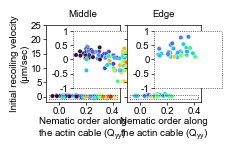

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['cut_type'] == 'wt']
data_subset = data_subset.loc[data_subset['orientation']=='para']
data_subset['no_qxx'] = -data_subset['no_qxx']
data_subset = data_subset.loc[data_subset['where'].isin(['middle', 'edge'])]

# plot
fig, axs = plt.subplots(1,2,figsize=[2, 1], gridspec_kw={'wspace': 0.1}, sharey=True)
sns.scatterplot(data = data_subset.loc[data_subset['where']=='middle'], x = 'no_qxx', y = 'rv', ax=axs[0], legend=False,
                s=10,
                hue = 'mpf', hue_norm = (43, 65), palette = 'turbo')
sns.scatterplot(data = data_subset.loc[data_subset['where']=='edge'], x = 'no_qxx', y = 'rv', ax=axs[1], legend=False,
                s=10,
                hue = 'mpf', hue_norm = (43, 65), palette = 'turbo')


axs[0].set_ylabel('Initial recoiling velocity\n(\u03BCm/sec)')
axs[0].set_title('Middle', fontsize=7)
axs[1].set_title('Edge', fontsize=7)
[ax.set_xlabel('Nematic order along\nthe actin cable ($\\mathregular{Q_{yy}}$)') for ax in axs]
[ax.set_xlim(-0.1, 0.45) for ax in axs]
[ax.set_xticks(np.arange(0, 0.5, 0.2)) for ax in axs]
[ax.set_ylim(-2, 25) for ax in axs]
[ax.set_yticks(np.arange(0, 26, 5)) for ax in axs]

# insets
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = axs[0].inset_axes([0.1, 3, 0.43+0.075, 20], transform=axs[0].transData,
                          xlim=[-0.075, 0.43], ylim=[-1, 1],
                          xticks=[], xticklabels=[],
                          yticks=[-1, -0.5, 0, 0.5, 1], yticklabels=[-1, -0.5, 0, 0.5, 1],
                          xlabel=' ', ylabel=' ', zorder=10)
axs[0].add_patch(plt.Rectangle( (-0.075, -1), 0.43-(-0.075), 0.6-(-1), fill=False, clip_on=False, color = 'black', lw=0.5, ls=':', zorder=20))
for spine in axins.spines.values():
    spine.set_color('black') 
    spine.set_linewidth(0.5)
    spine.set_linestyle(':')
    spine.set_capstyle('butt')

axins1 = axs[1].inset_axes([0.1, 3, 0.43+0.075, 20], transform=axs[1].transData,
                          xlim=[-0.075, 0.43], ylim=[-1, 1],
                          xticks=[], xticklabels=[],
                          yticks=[-1, -0.5, 0, 0.5, 1], yticklabels=[-1, -0.5, 0, 0.5, 1],
                          xlabel=' ', ylabel=' ', zorder=10)
axs[1].add_patch(plt.Rectangle( (-0.075, -1), 0.43-(-0.075), 0.6-(-1), fill=False, clip_on=False, color = 'black', lw=0.5, ls=':', zorder=20))
for spine in axins1.spines.values():
    spine.set_color('black') 
    spine.set_linewidth(0.5)
    spine.set_linestyle(':')
    spine.set_capstyle('butt')

sns.scatterplot(data = data_subset.loc[data_subset['where']=='middle'], x = 'no_qxx', y = 'rv', ax=axins, legend=False,
                s=10,
                hue = 'mpf', hue_norm = (43, 65), palette = 'turbo')
sns.scatterplot(data = data_subset.loc[data_subset['where']=='edge'], x = 'no_qxx', y = 'rv', ax=axins1, legend=False,
                s=10,
                hue = 'mpf', hue_norm = (43, 65), palette = 'turbo')

plt.savefig('rvwtparallel-no_middle_and_edge.svg')
plt.show()


In [ ]:
# statistics - counts
data_subset['bign'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')
data_subset['smalln'] = data_subset['experiment'] + data_subset['embryo_no'].astype('int').astype('str')

print('middle',
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].experiment)),
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].bign)),
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].smalln)),
      len(data_subset.loc[data_subset['where']=='middle']))
print('edge',
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].experiment)),
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].bign)),
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].smalln)),
      len(data_subset.loc[data_subset['where']=='edge']))

middle 5 10 59 102
edge 4 8 33 34


In [ ]:
# export excel
data_subset[['no_qxx', 'rv', 'where', 'mpf', 'experiment', 'cut_type', 'batch', 'embryo_no']].to_excel('rvwtparallel-no_middle_and_edge_excel_fig4bprime.xlsx', index=False)

### plot for the paper (fig. 4B) - colorbar

C:\Users\xtong\AppData\Local\Temp\ipykernel_12688\373400105.py:7: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig('rvwt-no_middle_and_edge_colorbar.svg')
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


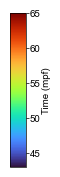

In [ ]:
fig, ax = plt.subplots(figsize=(0.2, 2), layout='constrained')
fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=43, vmax=65),
                                   cmap='turbo'),
                                   cax=ax, orientation='vertical')
ax.set_ylabel('Time (mpf)', fontsize=7)
# ax.set_yticks(np.arange(0,330,50))
plt.savefig('rvwt-no_middle_and_edge_colorbar.svg')
plt.show()

### make two new coloprs to distinguish wt and carhoa

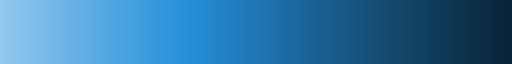

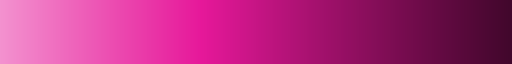

In [ ]:
def shaded_cmap(color="tab:blue", shade_range=[.2, .8]):
    import colorsys
    num = 1024
    color_rgb = mpl.colors.to_rgb(color)
    color_hls = colorsys.rgb_to_hls(color_rgb[0], color_rgb[1], color_rgb[2])
    shading = np.linspace(shade_range[0], shade_range[1], num)
    gamma = math.log(0.5) / math.log(color_hls[1])
    shading_conversion = np.exp(np.log(shading)/gamma)
    shaded_cmap = []
    for i in range(num):
        shaded_color = colorsys.hls_to_rgb(color_hls[0], shading_conversion[i], color_hls[2])
        shaded_cmap.append(shaded_color)
    
    # _,ax=plt.subplots(figsize=(3,2))
    # ax.scatter(range(num), shading_conversion, color=shaded_cmap)
    # ax.scatter((num-1)/2, color_hls[1], color=color, s=200)
    # ax.set_ylim(0,1)
    # ax.set_ylabel('Lightness')
    # plt.show()

    shaded_cmap = mpl.colors.ListedColormap(shaded_cmap)
    return shaded_cmap


def colored_line(x,y,c,ax, vmin='auto', vmax='auto', **lc_kwargs):
    
    from matplotlib.collections import LineCollection
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # c = (c-np.nanmin(c)) / (np.nanmax(c) - np.nanmin(c))
    # c = (c-vmin) / (vmax-vmin)
    # colors = plt.colormaps[cmap](c)

    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    if vmin == 'auto':
        vmin = c.min()
    if vmax == 'auto':
        vmax = c.max()

    lc = LineCollection(segments, **default_kwargs)
    if (vmin==0) and (vmax ==1):
        lc.set_array(c)
    else:
        lc.set_array(c)
        lc.set(clim=(vmin, vmax))

    return ax.add_collection(lc)


shaded_tab_blue = shaded_cmap("tab:blue", [0.8, 0.2])
shaded_mediumvioletred = shaded_cmap("mediumvioletred", [0.8, 0.2])

display(shaded_tab_blue)
display(shaded_mediumvioletred)

### plot for the paper (fig. 5C)
#### basic version (without stats)

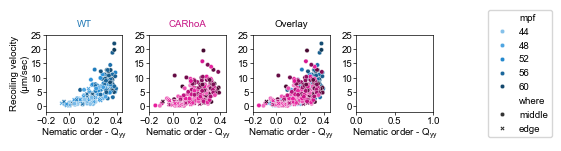

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['where'].isin(['middle', 'edge'])]
data_subset = data_subset.loc[data_subset['orientation']=='perp']

# plot
fig, axs = plt.subplots(1,4,figsize=[5, 1], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[0], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=10)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[1], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=10)
                # size=0.1, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=True, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=10)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=10)
                # size=0.1, color = 'mediumvioletred')

axs[0].set_ylabel('Recoiling velocity\n(\u03BCm/sec)')
axs[1].set_ylabel('')
axs[2].set_ylabel('')
axs[3].set_ylabel('')

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)

[ax.set_xlabel('Nematic order - $\\mathregular{Q_{yy}}$') for ax in axs]
[ax.set_xlim(-0.2, 0.45) for ax in axs[:3]]
[ax.set_xticks(np.arange(-0.2, 0.5, 0.2)) for ax in axs[:3]]
[ax.set_ylim(-2, 25) for ax in axs]
[ax.set_yticks(np.arange(0, 26, 5)) for ax in axs]

axs[2].legend(loc='center left', bbox_to_anchor=(3, 0.5), frameon=True, fontsize=7)

plt.savefig('rvmiddlevertical-noqyy_wt_and_carhoa.svg')
plt.show()

#### binned with nematic order

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['where'].isin(['middle', 'edge'])]
data_subset = data_subset.loc[data_subset['orientation']=='perp']

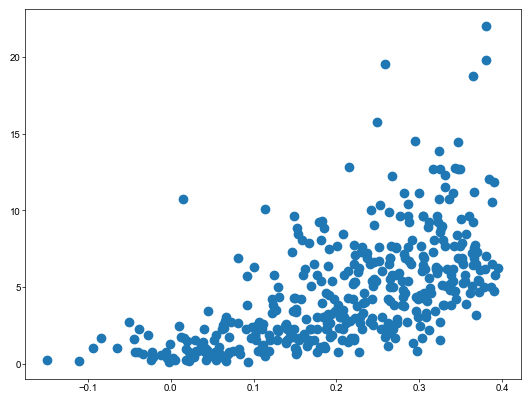

In [ ]:
plt.scatter(data_subset['no_qxx'], data_subset['rv'])

[-0.25 -0.15 -0.05  0.05  0.15  0.25  0.35  0.45]
Group -0.2
--Mann-Whitney U test (two-sided)--
Mann-Whitney U statistic = nan
p-value = nan
Statistical test, Mann-Whitney test: p = nan.
 
Group -0.1
--Mann-Whitney U test (two-sided)--
Mann-Whitney U statistic = 3.0
p-value = 1.0
Statistical test, Mann-Whitney test: p = 1.000.
 
Group -0.0
--Mann-Whitney U test (two-sided)--
Mann-Whitney U statistic = 157.5
p-value = 0.22278765898530994
Statistical test, Mann-Whitney test: p = 0.223.
 
Group 0.1
--Mann-Whitney U test (two-sided)--
Mann-Whitney U statistic = 698.5
p-value = 0.5108870209134428
Statistical test, Mann-Whitney test: p = 0.511.
 
Group 0.2
--Mann-Whitney U test (two-sided)--
Mann-Whitney U statistic = 1613.0
p-value = 0.7206794411100468
Statistical test, Mann-Whitney test: p = 0.721.
 
Group 0.3
--Mann-Whitney U test (two-sided)--
Mann-Whitney U statistic = 3022.5
p-value = 0.00014443489877233906
Statistical test, Mann-Whitney test: ***p < 0.001.
 
Group 0.4
--Mann-Whitney 

C:\Users\xtong\AppData\Local\Temp\ipykernel_12688\1611325718.py:20: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u_stat, p_val = scipy.stats.mannwhitneyu(testgroup1, testgroup2, alternative='two-sided')


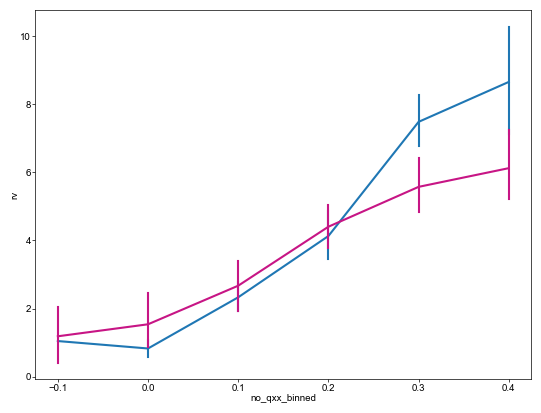

In [ ]:
# counts, bins = np.histogram(np.array(data_subset['no_qxx']).flatten(), bins=10)
# bin_labels = (bins[1:] + bins[:-1])/2
bins = np.linspace(-0.25, 0.45, 8)
bin_labels = np.round((bins[:-1] + bins[1:])/2, 1)
print(bins)

data_subset['no_qxx_binned'] = pd.cut(data_subset["no_qxx"], bins=bins, labels=bin_labels)
raw_pvals = []

for group in bin_labels:
    print('Group', group)
    a = data_subset.loc[data_subset.no_qxx_binned == group]

    group1 = a.loc[a.cut_type == 'wt'].rv
    group2 = a.loc[a.cut_type == 'carhoa'].rv

    testgroup1, testgroup2 = group1, group2

    # Mann–Whitney U test (two-sided)
    u_stat, p_val = scipy.stats.mannwhitneyu(testgroup1, testgroup2, alternative='two-sided')
    print('--Mann-Whitney U test (two-sided)--')
    print("Mann-Whitney U statistic =", u_stat)
    print("p-value =", p_val)
    print("Statistical test, Mann-Whitney test:", "***p < 0.001." if p_val<0.001 else f"p = {p_val:.4f}.")
    print(" ")
    raw_pvals.append(p_val)

raw_pvals = np.array(raw_pvals)
print("Raw:", np.round(raw_pvals,5))
# Bonferroni
rej_bonf, pvals_bonf, _, _ = multipletests(raw_pvals, alpha=0.05, method='bonferroni')
print("Bonferroni corrected:", np.round(pvals_bonf, 4))

sns.lineplot(data = data_subset, x = 'no_qxx_binned', y = 'rv', hue='cut_type', legend=False, err_style='bars', palette = ['tab:blue', 'mediumvioletred'])
plt.show()

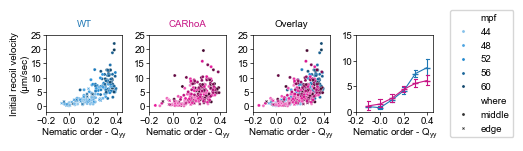

In [ ]:
# plot
fig, axs = plt.subplots(1,4,figsize=[5, 1], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[0], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[1], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=True, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'mediumvioletred')

# sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf',
#                 palette=shaded_tab_blue, hue_norm=(43, 65), s=7.5, alpha=.2)
# sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf',
#                 palette=shaded_mediumvioletred, hue_norm=(43, 65), s=7.5, alpha=.2)
# sns.lineplot(data = data_subset, x = 'no_qxx_binned', y = 'rv', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
#              err_style = 'band', errorbar=('ci', 95), lw=0.8)
# sns.lineplot(data = data_subset, x = 'no_qxx_binned', y = 'rv', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'], errorbar=('ci', 95), err_style = 'bars', lw=1.6)
sns.pointplot(data = data_subset, x = 'no_qxx_binned', y = 'rv', ax=axs[3], hue='cut_type', legend=False, palette = ['tab:blue', 'mediumvioletred'],
              estimator='mean', errorbar=('ci', 95), lw=0.8, marker='_', markersize=4, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8}, zorder=6)


axs[0].set_ylabel('Initial recoil velocity\n(\u03BCm/sec)')
[ax.set_ylabel('') for ax in axs[1:]]

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)

[ax.set_xlabel('Nematic order - $\\mathregular{Q_{yy}}$') for ax in axs]
[ax.set_xlim(-0.2, 0.45) for ax in axs[:3]]
[ax.set_xticks(np.arange(-0.2, 0.5, 0.2)) for ax in axs[:3]]
[ax.set_ylim(-2, 25) for ax in axs[:3]]
[ax.set_yticks(np.arange(0, 26, 5)) for ax in axs[:3]]

axs[3].set_xticks([0, 2, 4, 6])
axs[3].set_xlim(0, 6.5)
axs[3].set_ylim(0, 15)


axs[2].legend(loc='center left', bbox_to_anchor=(2.5, 0.5), frameon=True, fontsize=7)

plt.savefig('rvmiddlevertical-noqyy_wt_and_carhoa_2.svg')
plt.show()


#### binned with time

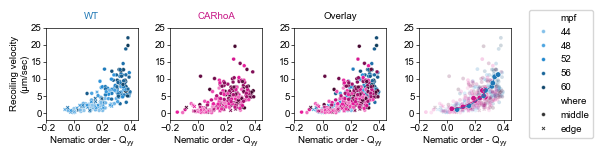

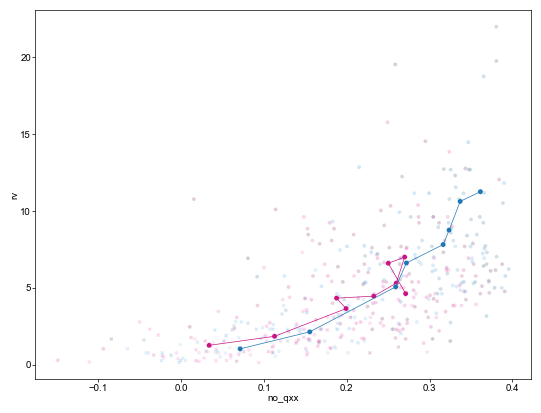

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['where'].isin(['middle', 'edge'])]
data_subset = data_subset.loc[data_subset['orientation']=='perp']

time_bin_width = 3
data_subset['time_bin'] = time_bin_width * np.round(data_subset['mpf'] / time_bin_width).astype('int')

# plot
fig, axs = plt.subplots(1,4,figsize=[6, 1.2], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[0], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[1], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=True, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'mediumvioletred')

# plot the last one
grouped = data_subset.groupby(['time_bin', 'cut_type', 'where']).agg(no_qxx_mean=('no_qxx', 'mean'), no_qxx_std=('no_qxx', 'std'),
                                                                     rv_mean=('rv', 'mean'), rv_std=('rv', 'std')).reset_index()
grouped = grouped.sort_values(['where', 'cut_type', 'time_bin'])

sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=7.5, alpha=.2)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=7.5, alpha=.2)
                # size=0.1, color = 'mediumvioletred')
sns.lineplot(data=grouped.loc[grouped['where']=='middle'], x= 'no_qxx_mean', y='rv_mean', hue = 'cut_type',  palette = {'wt':'tab:blue', 'carhoa':'mediumvioletred'},
             estimator=None, sort=False, legend=False, linewidth=0.5)
sns.scatterplot(data=grouped.loc[grouped['where']=='middle'], x= 'no_qxx_mean', y='rv_mean', hue = 'cut_type',  palette = {'wt':'tab:blue', 'carhoa':'mediumvioletred'},
                legend=False, s=15)

axs[0].set_ylabel('Recoiling velocity\n(\u03BCm/sec)')
[ax.set_ylabel('') for ax in axs[1:]]

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)

[ax.set_xlabel('Nematic order - $\\mathregular{Q_{yy}}$') for ax in axs]
[ax.set_xlim(-0.2, 0.45) for ax in axs]
[ax.set_xticks(np.arange(-0.2, 0.5, 0.2)) for ax in axs]
[ax.set_ylim(-2, 25) for ax in axs]
[ax.set_yticks(np.arange(0, 26, 5)) for ax in axs]

axs[2].legend(loc='center left', bbox_to_anchor=(2.5, 0.5), frameon=True, fontsize=7)

plt.savefig('rvmiddlevertical-noqyy_wt_and_carhoa_3.svg')
plt.show()


# to view at a meeting
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=7.5, alpha=.2)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=7.5, alpha=.2)
                # size=0.1, color = 'mediumvioletred')
sns.lineplot(data=grouped.loc[grouped['where']=='middle'], x= 'no_qxx_mean', y='rv_mean', hue = 'cut_type',  palette = {'wt':'tab:blue', 'carhoa':'mediumvioletred'},
             estimator=None, sort=False, legend=False, linewidth=0.5)
sns.scatterplot(data=grouped.loc[grouped['where']=='middle'], x= 'no_qxx_mean', y='rv_mean', hue = 'cut_type',  palette = {'wt':'tab:blue', 'carhoa':'mediumvioletred'},
                legend=False, s=15)
plt.show()

#### no binning - fit to $y = \beta x$ (proportional fit)

                                 OLS Regression Results                                
Dep. Variable:                     rv   R-squared (uncentered):                   0.769
Model:                            OLS   Adj. R-squared (uncentered):              0.767
Method:                 Least Squares   F-statistic:                              680.6
Date:                Thu, 17 Sep 2026   Prob (F-statistic):                   5.26e-131
Time:                        16:32:42   Log-Likelihood:                         -1012.3
No. Observations:                 412   AIC:                                      2029.
Df Residuals:                     410   BIC:                                      2037.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

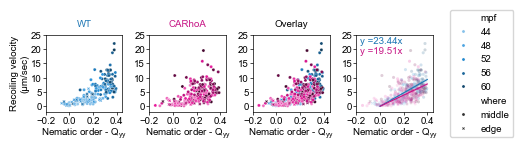

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['where'].isin(['middle', 'edge'])]
data_subset = data_subset.loc[data_subset['orientation']=='perp']

# plot
fig, axs = plt.subplots(1,4,figsize=[5, 1], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[0], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[1], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=True, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'mediumvioletred')

sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=5, alpha=.2)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=5, alpha=.2)
                # size=0.1, color = 'mediumvioletred')

# proportional fit
import statsmodels.formula.api as smf
# Fit y = k*x with a separate slope per category (no intercept)
model_zero = smf.ols("rv ~ 0 + no_qxx : cut_type", data=data_subset).fit()
print(model_zero.summary())
print('-.-.-.-.-.-.-')
print(model_zero.f_test("no_qxx:cut_type[wt] = no_qxx:cut_type[carhoa]"))
print('-.-.-.-.-.-.-')
wald_t = model_zero.t_test("no_qxx:cut_type[wt] = no_qxx:cut_type[carhoa]")
print(wald_t)
print(f"t = {wald_t.tvalue.item():.4f}, p = {wald_t.pvalue.item():.4f}")
print('-.-.-.-.-.-.-')

for cut_type, cut_type_color, annotation_y_pos in zip(['wt', 'carhoa'], ['tab:blue', 'mediumvioletred'], [22, 18.5]):
    # Build prediction dataframe
    no_qxx_pred = np.linspace(0, 0.4, 10)
    pred_df = pd.DataFrame({"no_qxx": no_qxx_pred,"cut_type": cut_type})
    # Get predictions with confidence intervals
    pred = model_zero.get_prediction(pred_df)
    pred_summary = pred.summary_frame(alpha=0.05)  # 95% CI
    beta = model_zero.params["no_qxx:cut_type[" + cut_type + "]"]

    axs[3].plot(no_qxx_pred, pred_summary["mean"], color=cut_type_color, lw=0.8)
    axs[3].fill_between( no_qxx_pred, pred_summary["mean_ci_lower"],pred_summary["mean_ci_upper"],alpha=0.2, color=cut_type_color, edgecolor=None)
    axs[3].text(x=-0.17, y=annotation_y_pos, s = f'y ={round(beta, 2)}x', color=cut_type_color)

axs[0].set_ylabel('Recoiling velocity\n(\u03BCm/sec)')
[ax.set_ylabel('') for ax in axs[1:]]

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)

[ax.set_xlabel('Nematic order - $\\mathregular{Q_{yy}}$') for ax in axs]
[ax.set_xlim(-0.2, 0.45) for ax in axs]
[ax.set_xticks(np.arange(-0.2, 0.5, 0.2)) for ax in axs]
[ax.set_ylim(-2, 25) for ax in axs]
[ax.set_yticks(np.arange(0, 26, 5)) for ax in axs]

axs[2].legend(loc='center left', bbox_to_anchor=(2.5, 0.5), frameon=True, fontsize=7)

plt.savefig('rvmiddlevertical-noqyy_wt_and_carhoa_4.svg')
plt.show()



In [ ]:
data_subset[['no_qxx', 'rv', 'where', 'mpf', 'experiment', 'cut_type', 'batch', 'embryo_no']].to_excel('rvmiddlevertical-noqyy_wt_and_carhoa_4_excel_fig5c.xlsx', index=False)

In [ ]:
model_zero.params[0] / model_zero.params[1]

C:\Users\xtong\AppData\Local\Temp\ipykernel_12688\385984489.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_zero.params[0] / model_zero.params[1]


np.float64(0.8323068889752326)

In [ ]:
model_zero.params

no_qxx:cut_type[carhoa]    19.506187
no_qxx:cut_type[wt]        23.436292
dtype: float64

#### no binning - fit to $y = e^{\beta x} - 1$

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
from scipy.stats import f

def model_beta(x, beta):
    return np.exp(beta * x) - 1.0

def fit_shared_beta(x, y):
    # params: [beta]
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    def resid(p):
        (beta,) = p
        return y - model_beta(x, beta)

    # initial guess: 0 is usually safe
    p0 = np.array([0.0], dtype=float)
    res = least_squares(resid, x0=p0)
    rss = float(np.sum(res.fun**2))
    return res.x, rss, res

def fit_separate_beta(x1, y1, x2, y2):
    # params: [beta1, beta2]
    x1 = np.asarray(x1, float); y1 = np.asarray(y1, float)
    x2 = np.asarray(x2, float); y2 = np.asarray(y2, float)

    def resid(p):
        beta1, beta2 = p
        r1 = y1 - model_beta(x1, beta1)
        r2 = y2 - model_beta(x2, beta2)
        return np.concatenate([r1, r2])

    p0 = np.array([0.0, 0.0], dtype=float)
    res = least_squares(resid, x0=p0)
    rss = float(np.sum(res.fun**2))
    return res.x, rss, res

def f_test_nested(rss_restricted, rss_full, p_restricted, p_full, n_obs):
    dfn = p_full - p_restricted
    dfd = n_obs - p_full
    F = ((rss_restricted - rss_full) / dfn) / (rss_full / dfd)
    pval = f.sf(F, dfn, dfd)
    return float(F), float(pval), int(dfn), int(dfd)

def compare_exp_minus1_groups(df, xcol="A", ycol="B", gcol="C"):
    d = df[[xcol, ycol, gcol]].dropna()
    groups = list(pd.unique(d[gcol]))
    if len(groups) != 2:
        raise ValueError(f"Expected exactly 2 groups in {gcol}, found {len(groups)}: {groups}")

    g1, g2 = groups[0], groups[1]
    d1 = d[d[gcol] == g1]
    d2 = d[d[gcol] == g2]

    x1, y1 = d1[xcol].to_numpy(float), d1[ycol].to_numpy(float)
    x2, y2 = d2[xcol].to_numpy(float), d2[ycol].to_numpy(float)
    n = len(y1) + len(y2)

    # full: separate betas
    p_sep, rss_sep, _ = fit_separate_beta(x1, y1, x2, y2)  # 2 params

    # restricted: shared beta
    x_all = np.concatenate([x1, x2])
    y_all = np.concatenate([y1, y2])
    p_shared, rss_shared, _ = fit_shared_beta(x_all, y_all)  # 1 param

    F_curve, p_curve, _, _ = f_test_nested(rss_shared, rss_sep, p_restricted=1, p_full=2, n_obs=n)

    return {
        "groups": (g1, g2),
        "n": {g1: len(y1), g2: len(y2), "total": n},
        "shared_fit": {"beta": p_shared[0], "rss": rss_shared},
        "separate_fit": {"beta1": p_sep[0], "beta2": p_sep[1], "rss": rss_sep},
        "tests": {
            "same_curve_shared_beta_vs_separate_betas": {"F": F_curve, "p_value": p_curve}
        }
    }

# Example:
# res = compare_exp_minus1_groups(df, xcol="A", ycol="B", gcol="C")
# print(res)

{'groups': ('wt', 'carhoa'), 'n': {'wt': 183, 'carhoa': 229, 'total': 412}, 'shared_fit': {'beta': np.float64(6.38199165758194), 'rss': 3999.370487847695}, 'separate_fit': {'beta1': np.float64(6.5161944348808385), 'beta2': np.float64(6.189495301642657), 'rss': 3963.377194481737}, 'tests': {'same_curve_shared_beta_vs_separate_betas': {'F': 3.723402935403036, 'p_value': 0.05434456654640461}}}
{'F': 3.723402935403036, 'p_value': 0.05434456654640461}


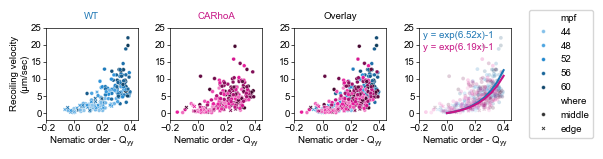

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['where'].isin(['middle', 'edge'])]
data_subset = data_subset.loc[data_subset['orientation']=='perp']

# plot
fig, axs = plt.subplots(1,4,figsize=[6, 1.2], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[0], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[1], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=True, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'mediumvioletred')

sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=7.5, alpha=.2)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=7.5, alpha=.2)
                # size=0.1, color = 'mediumvioletred')

# proportional fit
model = compare_exp_minus1_groups(df=data_subset, xcol="no_qxx", ycol="rv", gcol="cut_type")
print(model)
print(model["tests"]["same_curve_shared_beta_vs_separate_betas"])
for cut_type, cut_type_color, annotation_y_pos in zip(['wt', 'carhoa'], ['tab:blue', 'mediumvioletred'], [22, 18.5]):
    if cut_type == 'wt':
        beta = model['separate_fit']['beta1']
    else:
        beta = model['separate_fit']['beta2']

    no_qxx_pred = np.linspace(0, 0.4, 10)
    rv_pred = np.exp(beta * no_qxx_pred) -1
    axs[3].plot(no_qxx_pred, rv_pred, color=cut_type_color)
    axs[3].text(x=-0.17, y=annotation_y_pos, s = f'y = exp({round(beta, 2)}x)-1', color=cut_type_color)

axs[0].set_ylabel('Recoiling velocity\n(\u03BCm/sec)')
[ax.set_ylabel('') for ax in axs[1:]]

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)

[ax.set_xlabel('Nematic order - $\\mathregular{Q_{yy}}$') for ax in axs]
[ax.set_xlim(-0.2, 0.45) for ax in axs]
[ax.set_xticks(np.arange(-0.2, 0.5, 0.2)) for ax in axs]
[ax.set_ylim(-2, 25) for ax in axs]
[ax.set_yticks(np.arange(0, 26, 5)) for ax in axs]

axs[2].legend(loc='center left', bbox_to_anchor=(2.5, 0.5), frameon=True, fontsize=7)

plt.savefig('rvmiddlevertical-noqyy_wt_and_carhoa_5.svg')
plt.show()



#### no binning - fit to $y = e^{\alpha + \beta x}$

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
from scipy.stats import f

def exp_model(x, k, beta):
    return k * np.exp(beta * x)

def _initial_k(y):
    y = np.asarray(y)
    m = np.median(y[np.isfinite(y)]) if np.any(np.isfinite(y)) else 1.0
    return float(m) if m != 0 else 1.0

def fit_shared(x, y):
    # params: [k, beta]
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    def resid(p):
        k, beta = p
        return y - exp_model(x, k, beta)

    p0 = np.array([_initial_k(y), 0.0], dtype=float)
    res = least_squares(resid, x0=p0)
    rss = float(np.sum(res.fun**2))
    return res.x, rss, res

def fit_separate(x1, y1, x2, y2):
    # params: [k1, beta1, k2, beta2]
    x1 = np.asarray(x1, float); y1 = np.asarray(y1, float)
    x2 = np.asarray(x2, float); y2 = np.asarray(y2, float)

    def resid(p):
        k1, b1, k2, b2 = p
        r1 = y1 - exp_model(x1, k1, b1)
        r2 = y2 - exp_model(x2, k2, b2)
        return np.concatenate([r1, r2])

    p0 = np.array([_initial_k(y1), 0.0, _initial_k(y2), 0.0], dtype=float)
    res = least_squares(resid, x0=p0)
    rss = float(np.sum(res.fun**2))
    return res.x, rss, res

def fit_same_beta_diff_k(x1, y1, x2, y2):
    # params: [k1, k2, beta]
    x1 = np.asarray(x1, float); y1 = np.asarray(y1, float)
    x2 = np.asarray(x2, float); y2 = np.asarray(y2, float)

    def resid(p):
        k1, k2, beta = p
        r1 = y1 - exp_model(x1, k1, beta)
        r2 = y2 - exp_model(x2, k2, beta)
        return np.concatenate([r1, r2])

    p0 = np.array([_initial_k(y1), _initial_k(y2), 0.0], dtype=float)
    res = least_squares(resid, x0=p0)
    rss = float(np.sum(res.fun**2))
    return res.x, rss, res

def fit_same_k_diff_beta(x1, y1, x2, y2):
    # params: [k, beta1, beta2]
    x1 = np.asarray(x1, float); y1 = np.asarray(y1, float)
    x2 = np.asarray(x2, float); y2 = np.asarray(y2, float)

    def resid(p):
        k, b1, b2 = p
        r1 = y1 - exp_model(x1, k, b1)
        r2 = y2 - exp_model(x2, k, b2)
        return np.concatenate([r1, r2])

    p0 = np.array([_initial_k(np.concatenate([y1, y2])), 0.0, 0.0], dtype=float)
    res = least_squares(resid, x0=p0)
    rss = float(np.sum(res.fun**2))
    return res.x, rss, res

def f_test_nested(rss_restricted, rss_full, p_restricted, p_full, n_obs):
    """
    Restricted = simpler/null, Full = more complex/alt.
    p_* are number of parameters.
    """
    dfn = p_full - p_restricted
    dfd = n_obs - p_full
    F = ((rss_restricted - rss_full) / dfn) / (rss_full / dfd)
    pval = f.sf(F, dfn, dfd)
    return float(F), float(pval), int(dfn), int(dfd)

def compare_exponential_groups(df, xcol="A", ycol="B", gcol="C"):
    d = df[[xcol, ycol, gcol]].dropna()
    groups = list(pd.unique(d[gcol]))
    if len(groups) != 2:
        raise ValueError(f"Expected exactly 2 groups in {gcol}, found {len(groups)}: {groups}")

    g1, g2 = groups[0], groups[1]
    d1 = d[d[gcol] == g1]
    d2 = d[d[gcol] == g2]

    x1, y1 = d1[xcol].to_numpy(float), d1[ycol].to_numpy(float)
    x2, y2 = d2[xcol].to_numpy(float), d2[ycol].to_numpy(float)

    n = len(y1) + len(y2)

    # Full (separate curves)
    p_sep, rss_sep, _ = fit_separate(x1, y1, x2, y2)  # 4 params

    # Test 1: same curve? (shared vs separate)
    x_all = np.concatenate([x1, x2])
    y_all = np.concatenate([y1, y2])
    p_shared, rss_shared, _ = fit_shared(x_all, y_all)  # 2 params
    F_curve, p_curve, _, _ = f_test_nested(rss_shared, rss_sep, p_restricted=2, p_full=4, n_obs=n)

    # Test 2: same beta? (k differs allowed) => restricted 3 params vs full 4 params
    p_samebeta, rss_samebeta, _ = fit_same_beta_diff_k(x1, y1, x2, y2)  # 3 params
    F_beta, p_beta, _, _ = f_test_nested(rss_samebeta, rss_sep, p_restricted=3, p_full=4, n_obs=n)

    # Test 3: same k? (beta differs allowed) => restricted 3 params vs full 4 params
    p_samek, rss_samek, _ = fit_same_k_diff_beta(x1, y1, x2, y2)  # 3 params
    F_k, p_k, _, _ = f_test_nested(rss_samek, rss_sep, p_restricted=3, p_full=4, n_obs=n)

    results = {
        "groups": (g1, g2),
        "n": {g1: len(y1), g2: len(y2), "total": n},

        "shared_fit": {"k": p_shared[0], "beta": p_shared[1], "rss": rss_shared},
        "separate_fit": {"k1": p_sep[0], "beta1": p_sep[1], "k2": p_sep[2], "beta2": p_sep[3], "rss": rss_sep},

        "tests": {
            "same_curve_shared_vs_separate": {"F": F_curve, "p_value": p_curve},
            "same_beta": {"F": F_beta, "p_value": p_beta, "restricted_model": "k1,k2,beta"},
            "same_k": {"F": F_k, "p_value": p_k, "restricted_model": "k,beta1,beta2"},
        }
    }
    return results


{'groups': ('wt', 'carhoa'), 'n': {'wt': 183, 'carhoa': 229, 'total': 412}, 'shared_fit': {'k': np.float64(1.7065771106081895), 'beta': np.float64(4.311608169890692), 'rss': 3291.953263692935}, 'separate_fit': {'k1': np.float64(1.539031258076522), 'beta1': np.float64(4.88198463215731), 'k2': np.float64(2.0422669521015293), 'beta2': np.float64(3.3570309398551936), 'rss': 3182.1689360094133}, 'tests': {'same_curve_shared_vs_separate': {'F': 7.037967907361954, 'p_value': 0.0009885360059936508}, 'same_beta': {'F': 5.597045683100739, 'p_value': 0.018457454758833338, 'restricted_model': 'k1,k2,beta'}, 'same_k': {'F': 2.1275807206330732, 'p_value': 0.14543830925132392, 'restricted_model': 'k,beta1,beta2'}}}
{'F': 7.037967907361954, 'p_value': 0.0009885360059936508}


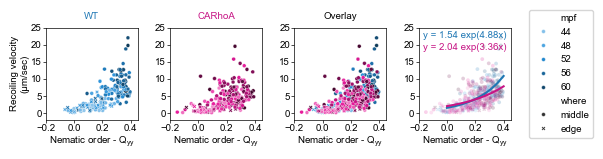

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['where'].isin(['middle', 'edge'])]
data_subset = data_subset.loc[data_subset['orientation']=='perp']

# plot
fig, axs = plt.subplots(1,4,figsize=[6, 1.2], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[0], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[1], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=True, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=7.5)
                # size=0.1, color = 'mediumvioletred')

sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=7.5, alpha=.2)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=7.5, alpha=.2)
                # size=0.1, color = 'mediumvioletred')

# fit
model = compare_exponential_groups(df=data_subset, xcol="no_qxx", ycol="rv", gcol="cut_type")
print(model)
print(model["tests"]["same_curve_shared_vs_separate"])

for cut_type, cut_type_color, annotation_y_pos in zip(['wt', 'carhoa'], ['tab:blue', 'mediumvioletred'], [22, 18.5]):
    if cut_type == 'wt':
        k = model['separate_fit']['k1']
        beta = model['separate_fit']['beta1']
    else:
        k = model['separate_fit']['k2']
        beta = model['separate_fit']['beta2']

    no_qxx_pred = np.linspace(0, 0.4, 10)
    rv_pred = k * np.exp(beta * no_qxx_pred)
    axs[3].plot(no_qxx_pred, rv_pred, color=cut_type_color)
    axs[3].text(x=-0.17, y=annotation_y_pos, s = f'y = {round(k, 2):.2f} exp({round(beta, 2)}x)', color=cut_type_color)


axs[0].set_ylabel('Recoiling velocity\n(\u03BCm/sec)')
[ax.set_ylabel('') for ax in axs[1:]]

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)

[ax.set_xlabel('Nematic order - $\\mathregular{Q_{yy}}$') for ax in axs]
[ax.set_xlim(-0.2, 0.45) for ax in axs]
[ax.set_xticks(np.arange(-0.2, 0.5, 0.2)) for ax in axs]
[ax.set_ylim(-2, 25) for ax in axs]
[ax.set_yticks(np.arange(0, 26, 5)) for ax in axs]

axs[2].legend(loc='center left', bbox_to_anchor=(2.5, 0.5), frameon=True, fontsize=7)

plt.savefig('rvmiddlevertical-noqyy_wt_and_carhoa_6.svg')
plt.show()



In [ ]:
# statistics - counts
data_subset['bign'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')
data_subset['smalln'] = data_subset['experiment'] + data_subset['embryo_no'].astype('int').astype('str')
data_subset['catalog'] = data_subset['cut_type'] + data_subset['where']
# data_subset['smalln'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')+ data_subset['embryo_no'].astype('int').astype('str')

print('wtmiddle',
      len(np.unique(data_subset.loc[data_subset['catalog']=='wtmiddle'].experiment)),
      len(np.unique(data_subset.loc[data_subset['catalog']=='wtmiddle'].bign)),
      len(np.unique(data_subset.loc[data_subset['catalog']=='wtmiddle'].smalln)),
      len(data_subset.loc[data_subset['catalog']=='wtmiddle']))
print('wtedge',
      len(np.unique(data_subset.loc[data_subset['catalog']=='wtedge'].experiment)),
      len(np.unique(data_subset.loc[data_subset['catalog']=='wtedge'].bign)),
      len(np.unique(data_subset.loc[data_subset['catalog']=='wtedge'].smalln)),
      len(data_subset.loc[data_subset['catalog']=='wtedge']))
print('carhoamiddle',
      len(np.unique(data_subset.loc[data_subset['catalog']=='carhoamiddle'].experiment)),
      len(np.unique(data_subset.loc[data_subset['catalog']=='carhoamiddle'].bign)),
      len(np.unique(data_subset.loc[data_subset['catalog']=='carhoamiddle'].smalln)),
      len(data_subset.loc[data_subset['catalog']=='carhoamiddle']))
print('carhoaedge',
      len(np.unique(data_subset.loc[data_subset['catalog']=='carhoaedge'].experiment)),
      len(np.unique(data_subset.loc[data_subset['catalog']=='carhoaedge'].bign)),
      len(np.unique(data_subset.loc[data_subset['catalog']=='carhoaedge'].smalln)),
      len(data_subset.loc[data_subset['catalog']=='carhoaedge']))

wtmiddle 5 14 87 134
wtedge 5 12 39 49
carhoamiddle 8 21 110 202
carhoaedge 4 8 24 27


### plot for the paper (fig. 5C) - colorbars

C:\Users\xtong\AppData\Local\Temp\ipykernel_12688\3409199168.py:8: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig('rvmiddlevertical-noqyy_wt_and_carhoa_colorbar_1.svg')
C:\Users\xtong\AppData\Local\Temp\ipykernel_12688\3409199168.py:16: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig('rvmiddlevertical-noqyy_wt_and_carhoa_colorbar_2.svg')
c:\Users\xtong\AppData\Local\miniforge3\envs\xint\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


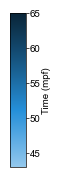

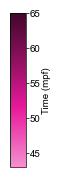

In [ ]:
# colorbars
fig, ax = plt.subplots(figsize=(0.2, 2), layout='constrained')
fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=43, vmax=65),
                                   cmap=shaded_tab_blue),
                                   cax=ax, orientation='vertical')
ax.set_ylabel('Time (mpf)', fontsize=7)
# ax.set_yticks(np.arange(0,330,50))
plt.savefig('rvmiddlevertical-noqyy_wt_and_carhoa_colorbar_1.svg')

fig, ax = plt.subplots(figsize=(0.2, 2), layout='constrained')
fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=43, vmax=65),
                                   cmap=shaded_mediumvioletred),
                                   cax=ax, orientation='vertical')
ax.set_ylabel('Time (mpf)', fontsize=7)
# ax.set_yticks(np.arange(0,330,50))
plt.savefig('rvmiddlevertical-noqyy_wt_and_carhoa_colorbar_2.svg')

## 5. Recoiling velocity ~ each embryo

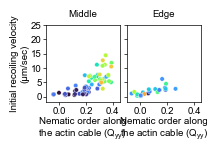

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.groupby(["experiment", "embryo_no"]).first().reset_index()

data_subset = data_subset.loc[data_subset['cut_type'] == 'wt']
data_subset = data_subset.loc[data_subset['orientation']=='perp']
data_subset = data_subset.loc[data_subset['where'].isin(['middle', 'edge'])]

# plot
fig, axs = plt.subplots(1,2,figsize=[2, 1], gridspec_kw={'wspace': 0.1}, sharey=True)
sns.scatterplot(data = data_subset.loc[data_subset['where']=='middle'], x = 'no_qxx', y = 'rv', ax=axs[0], legend=False,
                s=10,
                hue = 'mpf', hue_norm = (43, 65), palette = 'turbo')
sns.scatterplot(data = data_subset.loc[data_subset['where']=='edge'], x = 'no_qxx', y = 'rv', ax=axs[1], legend=False,
                s=10,
                hue = 'mpf', hue_norm = (43, 65), palette = 'turbo')


axs[0].set_ylabel('Initial recoiling velocity\n(\u03BCm/sec)')
# axs[1].set_ylabel('')
# axs[2].set_ylabel('')

axs[0].set_title('Middle', fontsize=7)
axs[1].set_title('Edge', fontsize=7)
# axs[2].set_title('Overlay', fontsize=12)


[ax.set_xlabel('Nematic order along\nthe actin cable ($\\mathregular{Q_{yy}}$)') for ax in axs]
[ax.set_xlim(-0.1, 0.45) for ax in axs]
[ax.set_xticks(np.arange(0, 0.5, 0.2)) for ax in axs]
[ax.set_ylim(-2, 25) for ax in axs]
[ax.set_yticks(np.arange(0, 26, 5)) for ax in axs]

# [ax.set_yscale('log') for ax in axs]
plt.savefig('rvwtvertical-no_middle_and_edge-only_first_cuts.svg')
plt.show()


In [ ]:
# statistics - counts
data_subset['bign'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')
data_subset['smalln'] = data_subset['experiment'] + data_subset['embryo_no'].astype('int').astype('str')

print('middle',
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].experiment)),
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].bign)),
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].smalln)),
      len(data_subset.loc[data_subset['where']=='middle']))
print('edge',
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].experiment)),
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].bign)),
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].smalln)),
      len(data_subset.loc[data_subset['where']=='edge']))

middle 4 11 62 62
edge 3 10 24 24


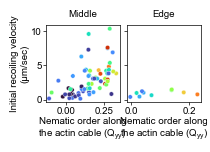

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.groupby(["experiment", "embryo_no"]).first().reset_index()

data_subset = data_subset.loc[data_subset['cut_type'] == 'carhoa']
data_subset = data_subset.loc[data_subset['orientation']=='perp']
data_subset = data_subset.loc[data_subset['where'].isin(['middle', 'edge'])]

# plot
fig, axs = plt.subplots(1,2,figsize=[2, 1], gridspec_kw={'wspace': 0.1}, sharey=True)
sns.scatterplot(data = data_subset.loc[data_subset['where']=='middle'], x = 'no_qxx', y = 'rv', ax=axs[0], legend=False,
                s=10,
                hue = 'mpf', hue_norm = (43, 65), palette = 'turbo')
sns.scatterplot(data = data_subset.loc[data_subset['where']=='edge'], x = 'no_qxx', y = 'rv', ax=axs[1], legend=False,
                s=10,
                hue = 'mpf', hue_norm = (43, 65), palette = 'turbo')


axs[0].set_ylabel('Initial recoiling velocity\n(\u03BCm/sec)')
# axs[1].set_ylabel('')
# axs[2].set_ylabel('')

axs[0].set_title('Middle', fontsize=7)
axs[1].set_title('Edge', fontsize=7)
# axs[2].set_title('Overlay', fontsize=12)


[ax.set_xlabel('Nematic order along\nthe actin cable ($\\mathregular{Q_{yy}}$)') for ax in axs]
# [ax.set_xlim(-0.1, 0.45) for ax in axs]
# [ax.set_xticks(np.arange(0, 0.5, 0.2)) for ax in axs]
# [ax.set_ylim(-2, 25) for ax in axs]
# [ax.set_yticks(np.arange(0, 26, 5)) for ax in axs]

# [ax.set_yscale('log') for ax in axs]
# plt.savefig('rvwtvertical-no_middle_and_edge-only_first_cuts.svg')
plt.show()


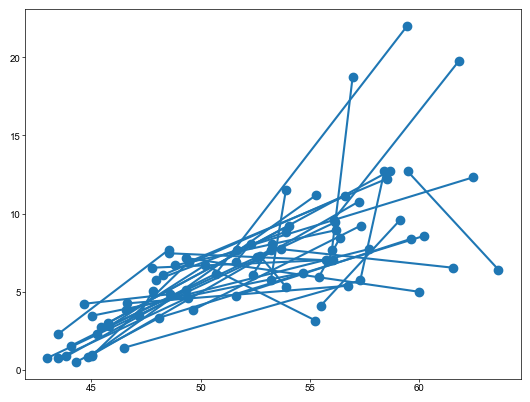

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['cut_type'] == 'wt']

data_subset = data_subset.loc[data_subset['where'] == 'middle']
data_subset = data_subset.loc[data_subset['orientation'] == 'perp']

for experiment in replicates_experiments[:]:
    data_subset_a = data_subset.loc[data_subset['experiment'] == experiment]
    embryo_nos = np.unique(data_subset_a['embryo_no'])
    for embryo_no in embryo_nos:
        data_subset_b = data_subset_a.loc[data_subset_a['embryo_no'] == embryo_no].sort_values('mpf')


        if len(data_subset_b) >=2:
            delta_noqxx = data_subset_b.no_qxx.iloc[0] - data_subset_b.no_qxx.iloc[-1]
            if delta_noqxx < 0:


                plt.plot(data_subset_b.mpf, data_subset_b.rv, color='tab:blue')
                plt.plot(data_subset_b.mpf, data_subset_b.rv, 'o', color='tab:blue')
            # plt.plot(data_subset_b.no_qxx, data_subset_b.rv, color='tab:blue')

# data_subset[['rep', 'experiment', 'batch', 'cut_no', 'where', 'orientation', 'embryo_no', 'rv', 'mpf']]

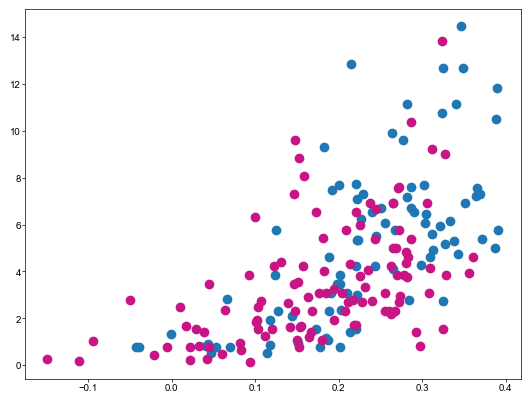

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['cut_type'] == 'wt']
data_subset = data_subset.loc[data_subset['where'] == 'middle']
data_subset = data_subset.loc[data_subset['orientation'] == 'perp']

for experiment in replicates_experiments[:]:
    data_subset_a = data_subset.loc[data_subset['experiment'] == experiment]
    embryo_nos = np.unique(data_subset_a['embryo_no'])
    for embryo_no in embryo_nos:
        data_subset_b = data_subset_a.loc[data_subset_a['embryo_no'] == embryo_no]
        data_subset_b = data_subset_b.iloc[0:1]
        # plt.plot(data_subset_b.mpf, data_subset_b.rv, color='tab:blue')
        plt.plot(data_subset_b.no_qxx, data_subset_b.rv, 'o', color='tab:blue')

data_subset = data_collection.copy()
data_subset = data_subset.loc[data_subset['cut_type'] == 'carhoa']
data_subset = data_subset.loc[data_subset['where'] == 'middle']
data_subset = data_subset.loc[data_subset['orientation'] == 'perp']

for experiment in replicates_experiments[:]:
    data_subset_a = data_subset.loc[data_subset['experiment'] == experiment]
    embryo_nos = np.unique(data_subset_a['embryo_no'])
    for embryo_no in embryo_nos:
        data_subset_b = data_subset_a.loc[data_subset_a['embryo_no'] == embryo_no]
        data_subset_b = data_subset_b.iloc[0:1]
        # plt.plot(data_subset_b.mpf, data_subset_b.rv, color='tab:blue')
        plt.plot(data_subset_b.no_qxx, data_subset_b.rv, 'o', color='mediumvioletred')

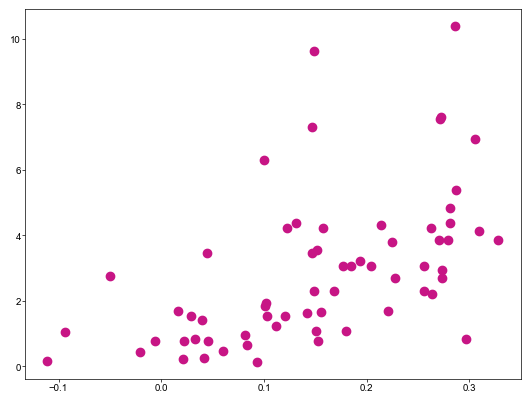

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.groupby(["experiment", "embryo_no"]).first().reset_index()

data_subset = data_subset.loc[data_subset['cut_type'] == 'carhoa']
data_subset = data_subset.loc[data_subset['where'] == 'middle']
data_subset = data_subset.loc[data_subset['orientation'] == 'perp']

plt.plot(data_subset.no_qxx, data_subset.rv, 'o', color='mediumvioletred')

                                 OLS Regression Results                                
Dep. Variable:                     rv   R-squared (uncentered):                   0.783
Model:                            OLS   Adj. R-squared (uncentered):              0.781
Method:                 Least Squares   F-statistic:                              285.7
Date:                Mon, 14 Sep 2026   Prob (F-statistic):                    3.29e-53
Time:                        14:25:39   Log-Likelihood:                         -341.34
No. Observations:                 160   AIC:                                      686.7
Df Residuals:                     158   BIC:                                      692.8
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

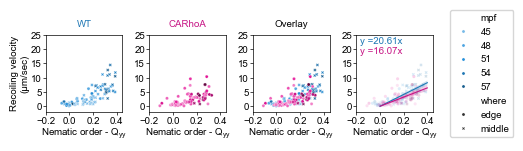

In [ ]:
data_subset = data_collection.copy()
data_subset = data_subset.groupby(["experiment", "embryo_no"]).first().reset_index()

data_subset = data_subset.loc[data_subset['where'].isin(['middle', 'edge'])]
data_subset = data_subset.loc[data_subset['orientation']=='perp']

# plot
fig, axs = plt.subplots(1,4,figsize=[5, 1], gridspec_kw={'wspace': 0.35})
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[0], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[1], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'mediumvioletred')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=True, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[2], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=5)
                # size=0.1, color = 'mediumvioletred')

sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='wt'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf', palette=shaded_tab_blue, hue_norm=(43, 65), s=5, alpha=.2)
                # size=0.1, color = 'tab:blue')
sns.scatterplot(data = data_subset.loc[data_subset['cut_type']=='carhoa'], x = 'no_qxx', y = 'rv', ax=axs[3], style='where', legend=False, hue='mpf', palette=shaded_mediumvioletred, hue_norm=(43, 65), s=5, alpha=.2)
                # size=0.1, color = 'mediumvioletred')

# proportional fit
import statsmodels.formula.api as smf
model_zero = smf.ols("rv ~ 0 + no_qxx : cut_type", data=data_subset).fit()
print(model_zero.summary())
print()
print(model_zero.f_test("no_qxx:cut_type[wt] = no_qxx:cut_type[carhoa]"))
print()
print(model_zero.t_test("no_qxx:cut_type[wt] = no_qxx:cut_type[carhoa]"))

for cut_type, cut_type_color, annotation_y_pos in zip(['wt', 'carhoa'], ['tab:blue', 'mediumvioletred'], [22, 18.5]):
    # Build prediction dataframe
    no_qxx_pred = np.linspace(0, 0.4, 10)
    pred_df = pd.DataFrame({"no_qxx": no_qxx_pred,"cut_type": cut_type})
    # Get predictions with confidence intervals
    pred = model_zero.get_prediction(pred_df)
    pred_summary = pred.summary_frame(alpha=0.05)  # 95% CI
    beta = model_zero.params["no_qxx:cut_type[" + cut_type + "]"]

    axs[3].plot(no_qxx_pred, pred_summary["mean"], color=cut_type_color, lw=0.8)
    axs[3].fill_between( no_qxx_pred, pred_summary["mean_ci_lower"],pred_summary["mean_ci_upper"],alpha=0.2, color=cut_type_color, edgecolor=None)
    axs[3].text(x=-0.17, y=annotation_y_pos, s = f'y ={round(beta, 2)}x', color=cut_type_color)

axs[0].set_ylabel('Recoiling velocity\n(\u03BCm/sec)')
[ax.set_ylabel('') for ax in axs[1:]]

axs[0].set_title('WT', fontsize=7, color='tab:blue')
axs[1].set_title('CARhoA', fontsize=7, color='mediumvioletred')
axs[2].set_title('Overlay', fontsize=7)

[ax.set_xlabel('Nematic order - $\\mathregular{Q_{yy}}$') for ax in axs]
[ax.set_xlim(-0.2, 0.45) for ax in axs]
[ax.set_xticks(np.arange(-0.2, 0.5, 0.2)) for ax in axs]
[ax.set_ylim(-2, 25) for ax in axs]
[ax.set_yticks(np.arange(0, 26, 5)) for ax in axs]

axs[2].legend(loc='center left', bbox_to_anchor=(2.5, 0.5), frameon=True, fontsize=7)

# plt.savefig('rvmiddlevertical-noqyy_wt_and_carhoa_4.svg')
plt.show()

In [ ]:
# statistics - counts
data_subset['bign'] = data_subset['experiment'] + data_subset['batch'].astype('int').astype('str')
data_subset['smalln'] = data_subset['experiment'] + data_subset['embryo_no'].astype('int').astype('str')

print('middle',
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].experiment)),
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].bign)),
      len(np.unique(data_subset.loc[data_subset['where']=='middle'].smalln)),
      len(data_subset.loc[data_subset['where']=='middle']))
print('edge',
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].experiment)),
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].bign)),
      len(np.unique(data_subset.loc[data_subset['where']=='edge'].smalln)),
      len(data_subset.loc[data_subset['where']=='edge']))

middle 11 28 126 126
edge 6 15 34 34


In [ ]:
combo_counts = data_subset.groupby(["cut_type", "where", "orientation"]).size().reset_index(name='count')
display(combo_counts)

,cut_type,where,orientation,count
0,carhoa,edge,perp,10
1,carhoa,middle,perp,64
2,wt,edge,perp,24
3,wt,middle,perp,62


# Different colormaps

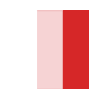

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(1,1))

ax.add_patch(patches.Rectangle((1/3, 0), 1/3, 1, color=(*plt.cm.tab10.colors[3], 0.2)))
ax.add_patch(patches.Rectangle((0, 0), 1/3, 1, color="white"))
ax.add_patch(patches.Rectangle((2/3, 0), 1/3, 1, color="tab:red"))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
c1 = 'white'
c2 = 'tab:red'
c3 = (*plt.cm.tab10.colors[3], 0.4)

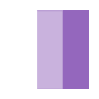

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(1,1))

ax.add_patch(patches.Rectangle((1/3, 0), 1/3, 1, color=(*plt.cm.tab10.colors[4], 0.5)))
ax.add_patch(patches.Rectangle((0, 0), 1/3, 1, color="white"))
ax.add_patch(patches.Rectangle((2/3, 0), 1/3, 1, color="tab:purple"))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.tight_layout()
plt.show()